#                                      Stroke Risk Prediction & Clinical Feature Engineering Project

#### 🎯 Business Understanding & Objective

According to the World Health Organization (WHO), stroke is the 2nd leading cause of death globally, responsible for approximately 11% of total deaths. This dataset is used to predict whether a patient is likely to get a stroke based on input parameters like gender, age, various diseases, and smoking status. Each row in the data provides relevant information about the patient. 

The objective of this study is to analyze the risk of patients suffering a stroke and the relationships between variables—based on gender, age, medical history (hypertension, heart disease), and lifestyle factors (smoking status, BMI)—using Exploratory Data Analysis (EDA) methods.

#### 📊 Dataset Attributes

The dataset contains 12 clinical features used to predict stroke events:

* **id:** Unique identifier for each patient
* **gender:** Gender of the patient
* **age:** Age of the patient
* **hypertension:** 0 if the patient doesn't have hypertension, 1 if they do
* **heart_disease:** 0 if the patient doesn't have any heart disease, 1 if they do
* **ever_married:** Marriage status ("No" or "Yes")
* **work_type:** Type of occupation ("children", "Govt_job", "Never_worked", "Private", or "Self-employed")
* **Residence_type:** Living area ("Rural" or "Urban")
* **avg_glucose_level:** Average glucose level in blood
* **bmi:** Body Mass Index
* **smoking_status:** Smoking history ("formerly smoked", "never smoked", "smokes", or "Unknown")
* **stroke:** Target variable — 1 if the patient had a stroke, 0 if not

---

#### 🛠️ Project Roadmap

1. **Environment & Data Loading:** Importing required Python libraries and reading the dataset.
2. **Initial Data Inspection:** Examining data structure, data types, shapes, and summary statistics (`head`, `info`, `describe`).
3. **Data Cleaning & Imputation:** Handling missing values in the `bmi` column using median imputation due to skewness and outliers.
4. **Column Standardization:** Cleaning and formatting column names for consistency.
5. **Exploratory Data Analysis (EDA):** Visualizing and analyzing relationships between demographic/medical factors and stroke occurrences.

## 1. Import Libraries, Loading the Dataset & Initial Exploration

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import missingno as msno
import plotly.express as px
import folium
from folium import plugins

import warnings
warnings.filterwarnings('ignore')

In [3]:
df0 = pd.read_csv("healthcare-dataset-stroke-data.csv")
df = df0.copy()

In [4]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [5]:
df.sample(5)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
537,23094,Male,65.0,0,0,Yes,Self-employed,Urban,105.61,27.9,Unknown,0
2760,3843,Female,24.0,0,0,No,Private,Urban,73.49,23.5,never smoked,0
2054,13964,Female,42.0,0,0,Yes,Private,Rural,107.91,20.5,never smoked,0
2921,47810,Male,8.0,0,0,No,children,Rural,107.97,26.7,Unknown,0
1104,17708,Male,62.0,0,0,Yes,Govt_job,Rural,204.57,34.4,Unknown,0


In [6]:
df.shape 

#The dataset consists of 5,110 observations (rows) and 12 features (columns).

(5110, 12)

In [7]:
df.info() 

#The df.info() output provides an initial structural overview of the dataset:

#Dataset Size:   Contains 5,110 entries and 12 columns, indexed sequentially from 0 to 5,109 (RangeIndex).
#Data Types:     Comprises 3 float64, 4 int64, and 5 object (categorical) features.
#Missing Values: All columns are non-null except for bmi, which contains missing values requiring imputation.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [8]:
df.describe().T 

,count,mean,std,min,25%,50%,75%,max
id,5110.0,36517.829354,21161.721625,67.00,17741.250,36932.000,54682.00,72940.00
age,5110.0,43.226614,22.612647,0.08,25.000,45.000,61.00,82.00
hypertension,5110.0,0.097456,0.296607,0.00,0.000,0.000,0.00,1.00
heart_disease,5110.0,0.054012,0.226063,0.00,0.000,0.000,0.00,1.00
avg_glucose_level,5110.0,106.147677,45.283560,55.12,77.245,91.885,114.09,271.74
bmi,4909.0,28.893237,7.854067,10.30,23.500,28.100,33.10,97.60
stroke,5110.0,0.048728,0.215320,0.00,0.000,0.000,0.00,1.00


#### 📈 Numerical Features Summary & Insights

An initial evaluation of the numerical variables from `df.describe()` yields the following findings:

* **Age (`age`):** 
  * The average age is **43.2**, ranging from **0.08 to 82 years**.
  * The close proximity of the mean (**43.2**) and median (**45.0**) suggests that the age distribution is relatively symmetric and close to a normal distribution.
  * Visual inspection (histogram / boxplot) will be used to confirm normality and detect potential outliers.

* **Average Glucose Level (`avg_glucose_level`):** 
  * Values range between **55.12 and 271.74**, with an average of **106.15**.
  * The mean (**106.15**) is notably higher than the median (**91.88**), indicating a **right-skewed distribution**.
  * The substantial gap between the 75th percentile (**114.09**) and the maximum value (**271.74**) strongly points to potential upper-bound outliers.

* **Body Mass Index (`bmi`):** 
  * Values range from **10.30 to 97.60**, with a mean of **28.89**.
  * The close values of the mean (**28.89**) and median (**28.10**) suggest a central distribution that is approximately symmetric.
  * However, the extreme maximum value (**97.60**) indicates the presence of significant high-end outliers, which will be further examined using IQR and boxplot visualizations.

## 2. Data Cleaning & Preprocessing

In [9]:
df.isnull().sum() 

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [10]:
print(f"Boş değer oranı: %{df['bmi'].isna().mean() * 100:.2f}")

Boş değer oranı: %3.93


Missing values are present only in the `bmi` column (201 out of 5,110 rows, ~4%).

Options to handle missing values:
1. **Leave** as missing
2. **Drop** missing rows using `dropna()`
3. **Impute** missing values using `fillna()`

To evaluate whether dropping or imputing is more appropriate—and to select the correct technique (e.g., mean vs. median)—we will first examine the distribution and outlier structure of the `bmi` feature.

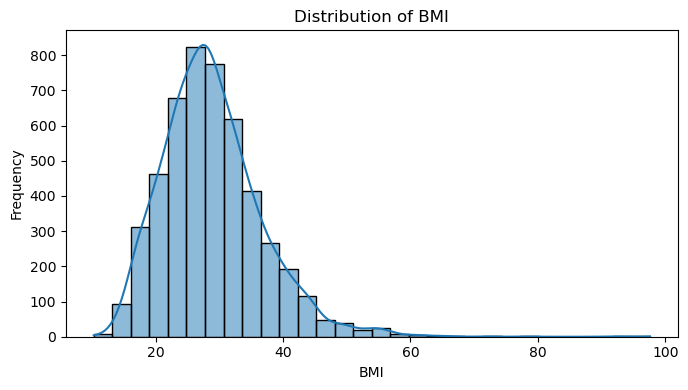

In [11]:
plt.figure(figsize=(7, 4))

sns.histplot(df["bmi"], bins=30, kde=True)

plt.title("Distribution of BMI")
plt.xlabel("BMI")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

**BMI Distribution Analysis**

The distribution of the `bmi` feature appears approximately normal across its central mass (concentrated between 20 and 35), forming a bell-shaped curve. 

However, a thin and extended right tail reaching up to 97.60 indicates mild right-skewness driven by extreme high values.

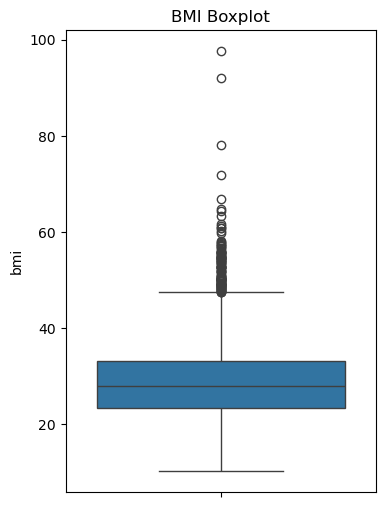

In [12]:
plt.figure(figsize=(4, 6))

sns.boxplot(y=df["bmi"])

plt.title("BMI Boxplot")

plt.show()

**BMI Boxplot Analysis**

The boxplot analysis confirms our initial findings, clearly revealing numerous upper-bound outliers beyond the upper whisker ($Q3 + 1.5 \times IQR$). 

While these extreme values (particularly $\text{BMI} > 50$) pull the distribution to the right, they may represent clinically valid cases of severe obesity and should be evaluated carefully rather than being blindly removed.

**DECISION**:

**Imputation Strategy & Justification:** Although statistical outliers are present in the upper tail, these values are considered biologically plausible (representing severe obesity cases) rather than data entry errors. To prevent data loss, we opted for missing value imputation instead of row removal. 

**Median imputation** was selected over mean imputation because the median is robust to extreme outliers, whereas the mean is significantly sensitive to high-end values and could introduce unwanted bias.

In [13]:
df["bmi"] = df["bmi"].fillna(df["bmi"].median())

In [14]:
df.isnull().sum() 

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

In [15]:
df.duplicated().sum() 

# No duplicate rows were detected in the dataset. All records are unique.

np.int64(0)

In [16]:
df.columns

# Upon examining the feature names, we observed that `Residence_type` relies on mixed casing (PascalCase with an underscore). 
# To maintain consistent naming conventions across the dataset (snake_case), it will be renamed to `residence_type`. 
# All other column names follow standard formats and require no adjustments.

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

In [17]:
new_column_names = {
    'Residence_type': 'residence_type'
                   }
df.rename(columns = new_column_names, inplace=True)

In [18]:
df.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

In [19]:
df.dtypes

# We will check the data types of our features and cast them if necessary to ensure proper formatting for downstream modeling.

id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

In [20]:
df.sample(2)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,residence_type,avg_glucose_level,bmi,smoking_status,stroke
3026,13439,Male,40.0,1,0,Yes,Private,Urban,90.91,39.1,Unknown,0
4508,24163,Female,12.0,0,0,No,children,Rural,116.04,23.8,Unknown,0


In [21]:
# We initially considered converting the `age` feature from `float` to `int` to drop the `.0` formatting. 
# However, further inspection revealed that ages for children under 1–2 years old are recorded 
# as precise fractional values (representing months or days). 
# To preserve this critical temporal precision, we retained `age` as a `float64`.

df[df["age"] % 1 != 0]["age"].sort_values().unique() 

# We filtered for non-integer (fractional) values in the `age` feature to inspect infants and young children. 
# The maximum non-integer age recorded is 1.88, confirming that fractional values are strictly limited to children under 2 years old.

array([0.08, 0.16, 0.24, 0.32, 0.4 , 0.48, 0.56, 0.64, 0.72, 0.8 , 0.88,
       1.08, 1.16, 1.24, 1.32, 1.4 , 1.48, 1.56, 1.64, 1.72, 1.8 , 1.88])

In [22]:
df[df["age"] < 3]["age"].sort_values().unique() 

# We verified non-integer values in the `age` column to confirm that 
# decimal representations apply strictly to infants and toddlers under 2 years old (up to 1.88 years).

array([0.08, 0.16, 0.24, 0.32, 0.4 , 0.48, 0.56, 0.64, 0.72, 0.8 , 0.88,
       1.  , 1.08, 1.16, 1.24, 1.32, 1.4 , 1.48, 1.56, 1.64, 1.72, 1.8 ,
       1.88, 2.  ])

**Binary Features & Data Types Summary**

We evaluated the `hypertension`, `heart_disease`, and `stroke` features, confirming they are binary categorical variables stored as integer flags (`0` and `1`). 

While converting them to `boolean` or `category` types is technically possible, retaining them as `int64` offers seamless compatibility with analytical functions and ML algorithm inputs.

**Conclusion:** All feature data types were validated, and no explicit type casting was required.

### 3. Categorical Feature Unique Value Inspection

Before moving to Exploratory Data Analysis (EDA), we inspect the unique values of all categorical features to detect any potential data entry errors, unexpected categories, or typos.

In [23]:
# Check unique values for categorical features.

cat_cols = ['gender', 'ever_married', 'work_type', 'residence_type', 'smoking_status']

for col in cat_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False))
    print("\n")

--- gender ---
gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64


--- ever_married ---
ever_married
Yes    3353
No     1757
Name: count, dtype: int64


--- work_type ---
work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64


--- residence_type ---
residence_type
Urban    2596
Rural    2514
Name: count, dtype: int64


--- smoking_status ---
smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64




#### Treatment of Rare Categorical Value

The `gender` feature contains a single instance ($n=1$) labeled as `Other` ($<0.02\%$ of the dataset). 

Keeping a single-observation category introduces statistical bias in subgroup analysis and visual noise in EDA charts. Therefore, this single record was removed from the dataset.

In [24]:
# Drop the single 'Other' record and reset DataFrame index

df = df[df['gender'] != 'Other'].reset_index(drop=True)

In [25]:
# Verify gender category counts

print(df['gender'].value_counts())

gender
Female    2994
Male      2115
Name: count, dtype: int64


In [26]:
df.shape

(5109, 12)

## 4. Exploratory Data Analysis & Visual Insights

### <span style=" color:red"> How does age influence stroke occurrence?
</span>

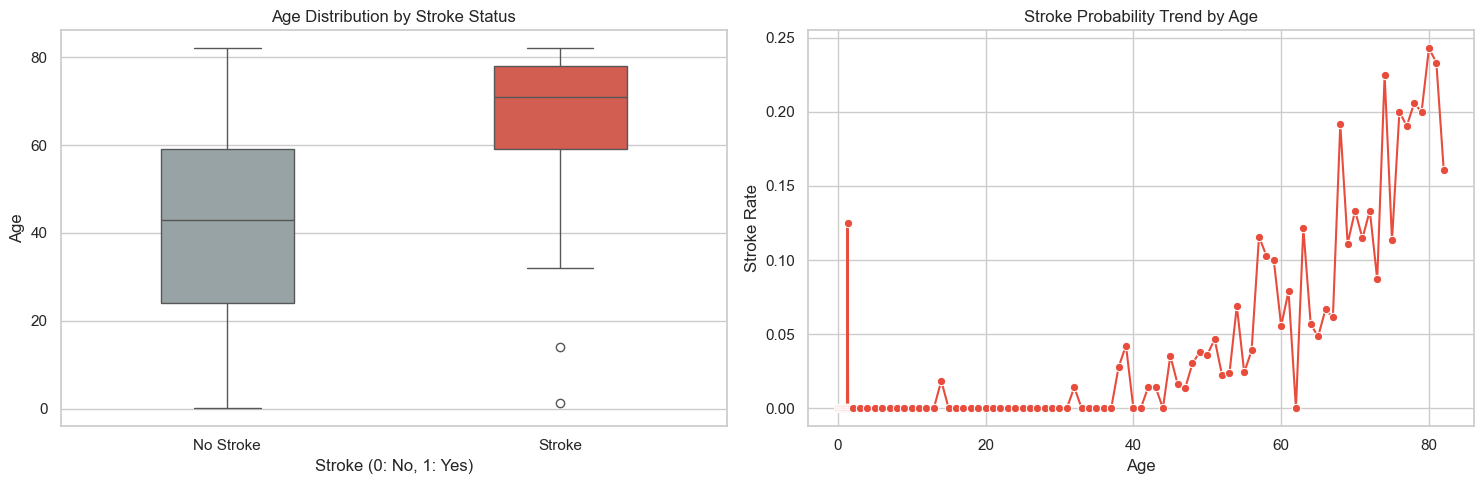

         count   mean    std   min   25%   50%   75%   max
stroke                                                    
0       4860.0  41.97  22.29  0.08  24.0  43.0  59.0  82.0
1        249.0  67.73  12.73  1.32  59.0  71.0  78.0  82.0


In [27]:
# 1. To visualize Age Distribution and Risk Trend side-by-side:

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left Panel: Boxplot:

sns.boxplot(data=df, x='stroke', y='age', hue='stroke', palette={0: "#95a5a6", 1: "#e74c3c"}, ax=axes[0], width=0.4, legend=False)
axes[0].set_title("Age Distribution by Stroke Status")
axes[0].set_xlabel("Stroke (0: No, 1: Yes)")
axes[0].set_ylabel("Age")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["No Stroke", "Stroke"])

# Right Panel: Risk Curve by Age:

stroke_rate = df.groupby("age")["stroke"].mean().reset_index()
sns.lineplot(data=stroke_rate, x="age", y="stroke", color="#e74c3c", marker="o", ax=axes[1])
axes[1].set_title("Stroke Probability Trend by Age")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Stroke Rate")

plt.tight_layout()
plt.show()

# 2. Age Distribution of Stroke Patients Only (Plotly Bar):

stroke_df = df[df["stroke"] == 1] # filter the dataset to analyze age distribution exclusively among stroke patients.
age_counts = stroke_df["age"].value_counts().sort_index().reset_index()
age_counts.columns = ["Age", "Stroke Count"]

fig = px.bar(age_counts, x="Age", y="Stroke Count", title="Stroke Cases Count by Age", color_discrete_sequence=["#e74c3c"], template="plotly_white")
fig.show()

# 3.  Statistical Summary

print(df.groupby('stroke')['age'].describe().round(2))

**Age & Stroke Conclusion**

1. **Statistical Summary & Distribution**
   
The stroke cohort exhibits a median age of 71.00 years and a mean age of 67.73 years. Compared to the non-stroke baseline (median: 43.00), the stroke group is significantly shifted toward older demographics. The mean being lower than the median confirms a left-skewed age distribution.

2. **Interquartile Concentration (Boxplot)**

The interquartile range (IQR) spans from 59.00 (Q1) to 78.00 (Q3) years, illustrating that 50% of all stroke cases are tightly clustered between ages 59 and 78.

3. **Age Trend, Thresholds & Outliers**

Outliers: Isolated early-onset cases at ages 1.32 and 14 represent lower-bound statistical outliers.

Risk Onset: Case frequency accelerates past age 42, exhibiting an upward trajectory with continuous fluctuations. 

Continuity & Peak: From age 50 onward, occurrence becomes near-continuous—with age 62 being the sole exception  with zero                         cases. The overall trend escalates to its peak frequency at age 78 (maximum age: 82).

4. **Methodological Note**

The strong relationship depicted in this chart demonstrates a high correlation between age and stroke frequency. However, based strictly on this visual data, this association indicates correlation rather than direct causation.

### <span style=" color:red"> Do body mass index (BMI) and glucose levels jointly or independently increase stroke risk?
</span>

In [28]:
df.head(1)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1


In [29]:
df["avg_glucose_level"].nunique()

3978

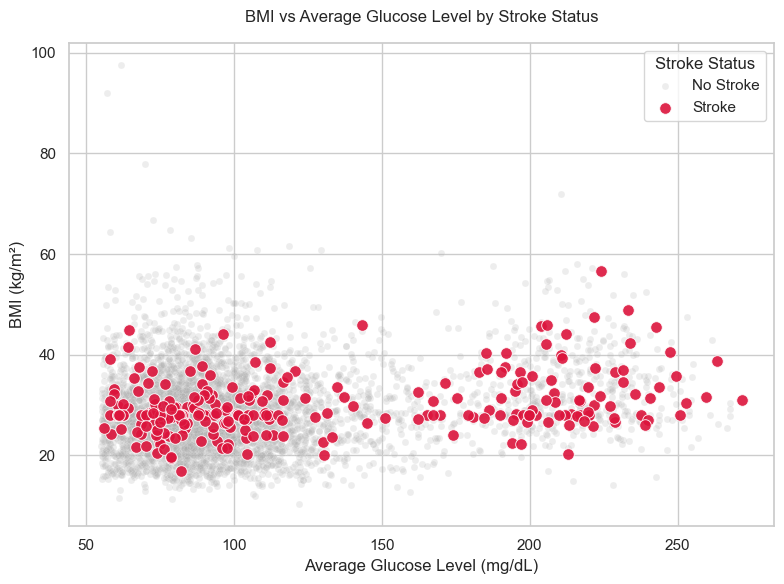

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

# No stroke

sns.scatterplot(
    data=df[df["stroke"] == 0],
    x="avg_glucose_level",
    y="bmi",
    color="darkgray",
    alpha=0.2,
    s=25,
    label="No Stroke"
)

# Stroke

sns.scatterplot(
    data=df[df["stroke"] == 1],
    x="avg_glucose_level",
    y="bmi",
    color="crimson",
    alpha=0.9,
    s=70,
    label="Stroke"
)

plt.title("BMI vs Average Glucose Level by Stroke Status", fontsize=12, pad=15)
plt.xlabel("Average Glucose Level (mg/dL)")
plt.ylabel("BMI (kg/m²)")
plt.legend(title="Stroke Status")
plt.tight_layout()
plt.show()

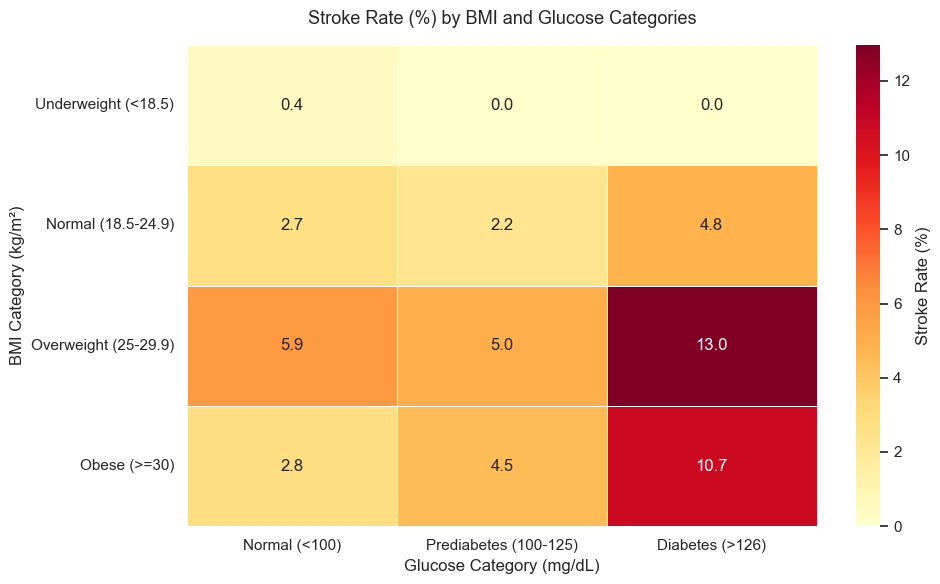

In [31]:
# 1. Create clinical categories:

df['bmi_cat'] = pd.cut(
    df['bmi'], 
    bins=[0, 18.5, 24.9, 29.9, 100], 
    labels=['Underweight (<18.5)', 'Normal (18.5-24.9)', 'Overweight (25-29.9)', 'Obese (>=30)']
) # We categorized the data based on BMI ranges

df['glucose_cat'] = pd.cut(
    df['avg_glucose_level'], 
    bins=[0, 99.99, 125.99, 300], 
    labels=['Normal (<100)', 'Prediabetes (100-125)', 'Diabetes (>126)']
) # We categorized the data based on average glucose levels.


# 2. Calculating stroke rate (%) per cell:

pivot_stroke = df.pivot_table(
    index='bmi_cat', 
    columns='glucose_cat', 
    values='stroke', 
    aggfunc=lambda x: np.mean(x) * 100
)

# 3. Heatmap

plt.figure(figsize=(10, 6))
sns.heatmap(
    pivot_stroke, 
    annot=True, 
    fmt=".1f", 
    cmap="YlOrRd", 
    cbar_kws={'label': 'Stroke Rate (%)'},
    linewidths=0.5
)

plt.title("Stroke Rate (%) by BMI and Glucose Categories", fontsize=13, pad=15)
plt.xlabel("Glucose Category (mg/dL)")
plt.ylabel("BMI Category (kg/m²)")
plt.tight_layout()
plt.show()

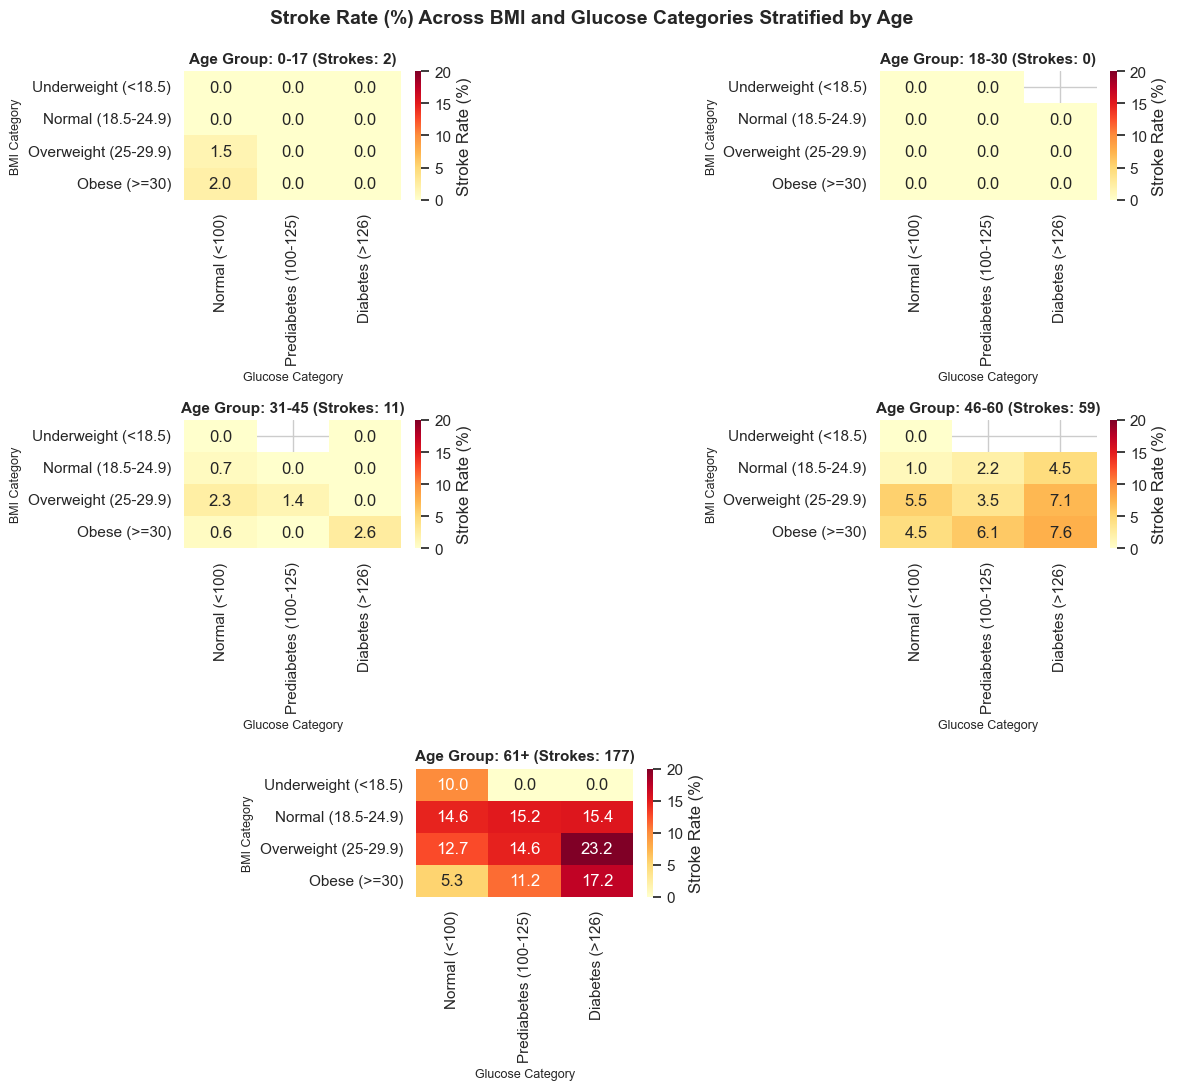

In [32]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Yaş Gruplarını Oluşturma
bins = [0, 18, 31, 46, 61, 150]
labels = ["0-17", "18-30", "31-45", "46-60", "61+"]
df["age_group"] = pd.cut(
    df["age"], bins=bins, labels=labels, right=False, include_lowest=True
)

# 2. Karakter Uzunlukları Eşit Düzeltilmiş Mosaic Düzeni (2-2-1)
# Her satır tam 5 karakter uzunluğunda:
layout = """
AA.BB
CC.DD
.EE..
"""

fig, axd = plt.subplot_mosaic(layout, figsize=(12, 11))
keys = ["A", "B", "C", "D", "E"]

for i, age_grp in enumerate(labels):
    ax = axd[keys[i]]
    sub_df = df[df["age_group"] == age_grp]

    pivot_sub = sub_df.pivot_table(
        index="bmi_cat",
        columns="glucose_cat",
        values="stroke",
        aggfunc=lambda x: np.mean(x) * 100 if len(x) > 0 else 0,
        observed=False,
    )

    sns.heatmap(
        pivot_sub,
        annot=True,
        fmt=".1f",
        cmap="YlOrRd",
        ax=ax,
        cbar_kws={"label": "Stroke Rate (%)"},
        vmin=0,
        vmax=20,
    )

    ax.set_title(
        f"Age Group: {age_grp} (Strokes: {sub_df['stroke'].sum()})",
        fontsize=11,
        fontweight="bold",
    )
    ax.set_xlabel("Glucose Category", fontsize=9)
    ax.set_ylabel("BMI Category", fontsize=9)

plt.suptitle(
    "Stroke Rate (%) Across BMI and Glucose Categories Stratified by Age",
    fontsize=14,
    fontweight="bold",
    y=0.99,
)
plt.tight_layout()
plt.show()

In [33]:
import numpy as np
import pandas as pd

# Age Group;

bins = [0, 18, 31, 46, 61, 150]
labels = ["0-17", "18-30", "31-45", "46-60", "61+"]
df["age_group"] = pd.cut(
    df["age"], bins=bins, labels=labels, right=False, include_lowest=True
)

# 1. Stroke Rate without Age Group;
overall_table = df.pivot_table(
    index="bmi_cat",
    columns="glucose_cat",
    values="stroke",
    aggfunc=lambda x: np.mean(x) * 100 if len(x) > 0 else 0,
    observed=False,
)

# 2. Stroke Rate with Age Group;
age_stratified_table = df.pivot_table(
    index=["age_group", "bmi_cat"],
    columns="glucose_cat",
    values="stroke",
    aggfunc=lambda x: np.mean(x) * 100 if len(x) > 0 else 0,
    observed=False,
)

print("=== OVERALL STROKE RATE (%) ===")
print(overall_table.round(1))

print("\n=== AGE-STRATIFIED STROKE RATE (%) ===")
print(age_stratified_table.round(1))

=== OVERALL STROKE RATE (%) ===
glucose_cat           Normal (<100)  Prediabetes (100-125)  Diabetes (>126)
bmi_cat                                                                    
Underweight (<18.5)             0.4                    0.0              0.0
Normal (18.5-24.9)              2.7                    2.2              4.8
Overweight (25-29.9)            5.9                    5.0             13.0
Obese (>=30)                    2.8                    4.5             10.7

=== AGE-STRATIFIED STROKE RATE (%) ===
glucose_cat                     Normal (<100)  Prediabetes (100-125)  \
age_group bmi_cat                                                      
0-17      Underweight (<18.5)             0.0                    0.0   
          Normal (18.5-24.9)              0.0                    0.0   
          Overweight (25-29.9)            1.5                    0.0   
          Obese (>=30)                    2.0                    0.0   
18-30     Underweight (<18.5)           

**BMI, Glucose Levels & Stroke Risk Conclusion**

This analysis evaluates whether Body Mass Index (BMI) and average glucose levels independently or jointly drive stroke risk, while controlling for age as the primary confounding factor.

1. **Independent Drive of Glucose Levels** Age-stratified findings confirm that **elevated average glucose levels** act as a **strong, independent driver of stroke risk** once individuals reach mature **age cohorts (46-60 and 61+)**:

In the 46–60 cohort: Transitioning from Normal glucose to Diabetes consistently increases stroke incidence across all BMI categories: Normal weight ($1.0\% \rightarrow 4.5\%$), Overweight ($5.5\% \rightarrow 7.1\%$), and Obese ($4.5\% \rightarrow 7.6\%$).
In the 61+ cohort: **Crossing the Diabetes threshold pushes stroke rates to their highest values across all weight classes**, peaking at 23.2% in Overweight and 17.2% in Obese individuals.
 
2. Absence of Linear Synergistic Risk Compounding: **The data does not support a purely linear or multiplicative interaction between high BMI and high glucose**:

**If a strict linear synergistic relationship existed, the highest stroke rate across every age group would systematically concentrate in the Obese + Diabetes cell.Instead**, both in the overall dataset (13.0%) and within the high-risk 61+ cohort (23.2%), **maximum stroke incidence concentrates in the Overweight + Diabetes group.**

3. Age Confounding and Sample Distribution Constraints:

Baseline Risk Threshold: Stroke risk remains negligible across virtually all BMI and glucose combinations below age 45. 

Explanation for Non-Linear Variation: The rate differential between the Overweight-Diabetic (23.2%) and Obese-Diabetic (17.2%) groups in the 61+ cohort does not indicate a protective effect of obesity. Rather, this variance may stem from reduced sub-bin sample sizes (sample size limitations) and statistical selection noise when partitioning the dataset across multiple categorical dimensions.

**Conclusion:** Average blood glucose level is a primary, independent risk factor for stroke in older adults. BMI and glucose do not compound stroke risk in a linear synergistic manner, and baseline age remains the primary confounding variable governing overall risk magnitude.

### <span style=" color:red"> Can smoking increase the likelihood of stroke?
</span>

In [34]:
df.head(1)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,residence_type,avg_glucose_level,bmi,smoking_status,stroke,bmi_cat,glucose_cat,age_group
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1,Obese (>=30),Diabetes (>126),61+


In [35]:
df["smoking_status"].unique()

array(['formerly smoked', 'never smoked', 'smokes', 'Unknown'],
      dtype=object)

In [36]:
pd.crosstab(df["smoking_status"], df["stroke"], normalize="index")

stroke,0,1
smoking_status,,
Unknown,0.969560,0.030440
formerly smoked,0.920814,0.079186
never smoked,0.952431,0.047569
smokes,0.946768,0.053232


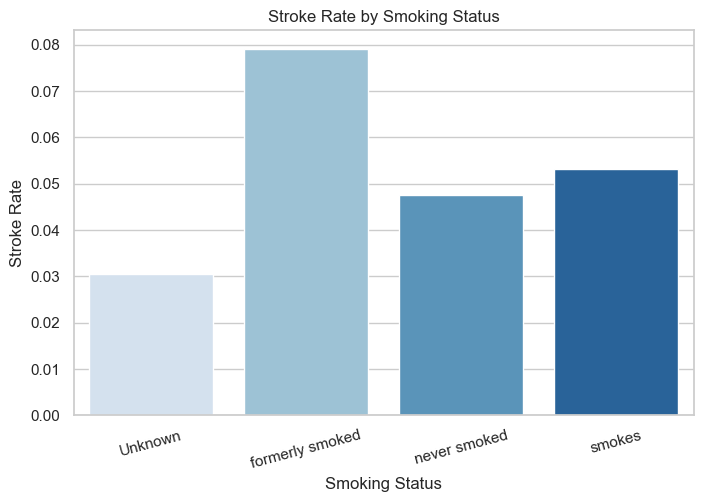

In [37]:
stroke_by_smoking = (
    df.groupby("smoking_status")["stroke"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=stroke_by_smoking,
    x="smoking_status",
    y="stroke",
    palette="Blues"
)

plt.title("Stroke Rate by Smoking Status")
plt.xlabel("Smoking Status")
plt.ylabel("Stroke Rate")

plt.xticks(rotation=15)

plt.show()

The unadjusted plot above suggests that **`formerly smoked`** individuals have the highest stroke rate, while the **`Unknown`** group appears to be at the lowest risk.
**However, this conclusion is misleading due to Simpson's Paradox.** Age acts as a key confounding variable: the `Unknown` category is heavily dominated by young individuals (where stroke incidence is near zero).
To isolate the true impact of smoking on stroke risk, we must control for age by segmenting the dataset into **age groups**.

**Next Step** 

In our previous analysis, we established age as a primary determinant of stroke risk. Building on that insight, we now segment the data by age groups to control for confounding effects and accurately isolate the impact of smoking.

In [38]:
# 1. Summary Table;

age_smoking_summary = (
    df.groupby(["age_group", "smoking_status"], observed=False)["stroke"]
    .agg(total_people="count", stroke_count="sum", stroke_mean="mean")
    .reset_index()
)

# Converting the stroke rate to percentage;

age_smoking_summary["stroke_pct"] = (
    age_smoking_summary["stroke_mean"] * 100
).round(2)


In [39]:
# 2. Plotly;

fig = px.bar(
    age_smoking_summary,
    x="age_group",
    y="stroke_pct",
    color="smoking_status",
    barmode="group",
    labels={
        "age_group": "Age Group",
        "stroke_pct": "Stroke Rate (%)",
        "smoking_status": "Smoking",
        "total_people": "Total People",
        "stroke_count": "Stroke Count",
    },
    title= "Stroke Rate by Age Group and Smoking Status (%)",
    hover_data={
        "stroke_pct": ":.2f%",      
        "total_people": True,        
        "stroke_count": True,          
        "stroke_mean": False           
    },
    color_discrete_sequence=px.colors.sequential.Blues_r,
)

fig.update_layout(
    xaxis_title="Age Group",
    yaxis_title="Stroke Rate (%)",
    legend_title="Smoking",
    template="plotly_white",
)

fig.show()

In [40]:
summary_table = df.groupby(['age_group', 'smoking_status'], observed=False)['stroke'].agg(
    total_people='count',
    stroke_count='sum',
    stroke_rate_pct=lambda x: round(x.mean() * 100, 2)
).reset_index()

print(summary_table)

   age_group   smoking_status  total_people  stroke_count  stroke_rate_pct
0       0-17          Unknown           682             2             0.29
1       0-17  formerly smoked            25             0             0.00
2       0-17     never smoked           140             0             0.00
3       0-17           smokes             9             0             0.00
4      18-30          Unknown           177             0             0.00
5      18-30  formerly smoked            71             0             0.00
6      18-30     never smoked           326             0             0.00
7      18-30           smokes           139             0             0.00
8      31-45          Unknown           220             2             0.91
9      31-45  formerly smoked           158             3             1.90
10     31-45     never smoked           448             3             0.67
11     31-45           smokes           222             3             1.35
12     46-60          Unk

**Smoking & Stroke Conclusion:**

When evaluating the direct relationship between smoking status and stroke rates in the **raw dataset**, a highly **misleading pattern** emerges. Unadjusted metrics suggest that former smokers experience the highest overall stroke rate (7.92%), while the "Unknown" category exhibits the lowest risk (3.04%). This counter-intuitive outcome is a classic manifestation of **Simpson's Paradox**, driven by age as a primary confounding variable. Specifically, 80% of the "Unknown" smoking group (682 out of 856 individuals) consists of children aged 0–17, a demographic where baseline stroke incidence is near zero (0.29%). Consequently, **this heavy concentration of young individuals artificially dilutes the aggregate stroke risk for the "Unknown" category.**

To isolate and eliminate this confounding age effect, the dataset was stratified into distinct **age cohorts** (0–17, 18–30, 31–45, 46–60, 61+). In lower age brackets, stroke events are virtually non-existent: the 18–30 cohort (658 individuals) recorded a 0.00% stroke rate across all smoking categories. **The true impact of smoking first diverges significantly within the 31–45 age cohort.** In this group, individuals who never smoked record a stroke rate of 0.67%, whereas active smokers reach 1.35% and former smokers reach 1.90%—demonstrating a 2 to 3-fold increase in relative stroke risk for those with a history of smoking.

**As age advances into the 46–60 cohort, overall stroke incidence increases across all subgroups, with active smokers maintaining the highest risk** (6.97% vs. 3.63% for never-smokers, representing nearly double the incidence). **However, in the 61+ senior cohort, stroke rates scale to double digits (12.57% to 14.36%) across all categories. In this advanced demographic, baseline age becomes the dominant risk driver,** causing the relative variance between smoking statuses to narrow significantly and converge within a tight 12–14% band.

Methodologically, proportion metrics were utilized to normalize for unequal group volumes across categories. Nevertheless, potential variance in ultra-small subgroups (such as the 0–17 active smoker group with n=9) must be acknowledged, meaning core analytical conclusions rely on adequately represented cohorts (n > 100). **In summary, the data proves that smoking status correlates with a sharp increase in stroke risk between ages 31 and 60, whereas after age 60, baseline age predominates as the primary risk factor.**

### <span style=" color:red"> Do individuals with heart disease face a higher stroke risk?
</span>

In [41]:
df.head(1)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,residence_type,avg_glucose_level,bmi,smoking_status,stroke,bmi_cat,glucose_cat,age_group
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1,Obese (>=30),Diabetes (>126),61+


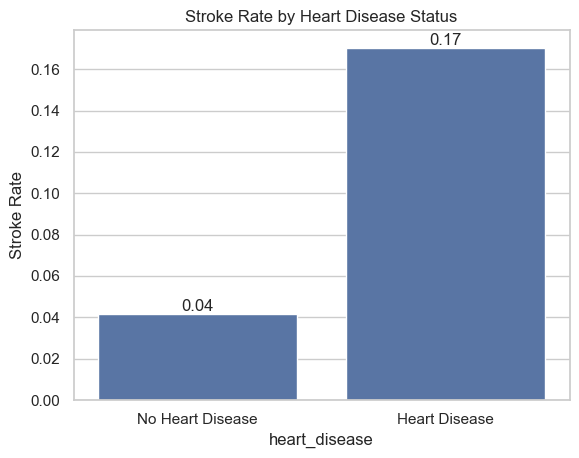

In [42]:
heart_stroke = df.groupby("heart_disease")["stroke"].mean().reset_index()

sns.barplot(data=heart_stroke, x="heart_disease", y="stroke")

plt.xticks([0, 1], ["No Heart Disease", "Heart Disease"])
plt.ylabel("Stroke Rate")
plt.title("Stroke Rate by Heart Disease Status")

plt.bar_label(plt.gca().containers[0], fmt="%.2f")

plt.show()

While the baseline metrics demonstrate a 4-fold increase in stroke risk for individuals with heart disease (17% vs. 4%), this aggregate figure may be confounded by age distribution. To determine whether heart disease acts as an independent clinical risk driver or primarily reflects age-related trends, the dataset was stratified across distinct age cohorts;

In [43]:
# Summary Table by Age Group and Heart Disease Status;

heart_age_summary = (
    df.groupby(["age_group", "heart_disease"], observed=False)["stroke"]
    .agg(total_people="count", stroke_count="sum", stroke_mean="mean")
    .reset_index()
)

# Calculate percentage;

heart_age_summary["stroke_pct"] = (
    heart_age_summary["stroke_mean"] * 100
).round(2)

print(heart_age_summary)

  age_group  heart_disease  total_people  stroke_count  stroke_mean  \
0      0-17              0           855             2     0.002339   
1      0-17              1             1             0     0.000000   
2     18-30              0           712             0     0.000000   
3     18-30              1             1             0     0.000000   
4     31-45              0          1042            11     0.010557   
5     31-45              1             6             0     0.000000   
6     46-60              0          1130            54     0.047788   
7     46-60              1            58             5     0.086207   
8       61+              0          1094           135     0.123400   
9       61+              1           210            42     0.200000   

   stroke_pct  
0        0.23  
1        0.00  
2        0.00  
3        0.00  
4        1.06  
5        0.00  
6        4.78  
7        8.62  
8       12.34  
9       20.00  


In [44]:
import plotly.express as px

fig = px.bar(
    heart_age_summary,
    x="age_group",
    y="stroke_pct",
    color="heart_disease",
    barmode="group",
    title="Stroke Rate by Age Group and Heart Disease Status (%)",
    labels={
        "age_group": "Age Group",
        "stroke_pct": "Stroke Rate (%)",
        "heart_disease": "Heart Disease (0=No, 1=Yes)",
        "total_people": "Total People",
        "stroke_count": "Stroke Count",
    },
    hover_data={
        "stroke_pct": ":.2f%",
        "total_people": True,
        "stroke_count": True,
        "stroke_mean": False,
    },
    template="plotly_white",
)

fig.show()

**Heart Disease & Stroke Conclusion** 

Initial unadjusted metrics indicate that individuals with heart disease exhibit a significantly higher overall stroke rate compared to those without the condition. Stratifying the data across age cohorts reveals that heart disease diagnoses are extremely rare in younger demographics, with a sample size of only 8 total individuals diagnosed with heart disease across the 0–45 age range (1 in 0–17, 1 in 18–30, and 6 in 31–45, with 0 stroke cases recorded among them), **making statistical inferences for younger groups unreliable.**

The clinical impact of heart disease becomes evident starting in the **46–60 age cohort**, where individuals with heart disease experience a markedly **higher stroke rate than those without (8.62% vs. 4.78%), nearly doubling the risk.**

This effect **peaks in the 61+** senior cohort, where heart disease elevates stroke incidence to 20.00% *—meaning exactly 1 in every 5 senior heart disease patients experienced a stroke—* compared to 12.34% among their peers without heart disease. **Unlike smoking status, where risk rates tended to converge in advanced age, heart disease functions as a strong, independent risk multiplier after age 46, accelerating stroke incidence in senior populations.**

### <span style=" color:red"> Does work-related stress contribute to hypertension and subsequently to strokes?
</span>

In [45]:
# Before age group

raw_work_summary = (
    df.groupby("work_type")
    .agg(
        total_people=("stroke", "count"),
        avg_age=("age", "mean"),
        stroke_cases=("stroke", "sum"),
        stroke_rate_pct=("stroke", lambda x: round(x.mean() * 100, 2)),
    )
    .reset_index()
)

raw_work_summary

,work_type,total_people,avg_age,stroke_cases,stroke_rate_pct
0,Govt_job,657,50.879756,33,5.02
1,Never_worked,22,16.181818,0,0.00
2,Private,2924,45.510602,149,5.10
3,Self-employed,819,60.201465,65,7.94
4,children,687,6.841339,2,0.29


In [46]:
# Filter only working group

working_df = df[
    df["work_type"].isin(["Private", "Self-employed", "Govt_job"])
]

# With Age Group;

work_age_stratified = (
    working_df.groupby(["age_group", "work_type"], observed=False)
    .agg(
        total_people=("stroke", "count"),
        hypertension_cases=("hypertension", "sum"),
        hypertension_rate_pct=(
            "hypertension",
            lambda x: round(x.mean() * 100, 2),
        ),
        stroke_cases=("stroke", "sum"),
        stroke_rate_pct=("stroke", lambda x: round(x.mean() * 100, 2)),
    )
    .reset_index()
)

In [47]:
work_age_stratified

,age_group,work_type,total_people,hypertension_cases,hypertension_rate_pct,stroke_cases,stroke_rate_pct
0,0-17,Govt_job,6,0,0.00,0,0.00
1,0-17,Private,134,1,0.75,0,0.00
2,0-17,Self-employed,12,0,0.00,0,0.00
3,18-30,Govt_job,63,1,1.59,0,0.00
4,18-30,Private,611,9,1.47,0,0.00
5,18-30,Self-employed,34,0,0.00,0,0.00
6,31-45,Govt_job,178,9,5.06,0,0.00
7,31-45,Private,749,32,4.27,8,1.07
8,31-45,Self-employed,121,12,9.92,3,2.48
9,46-60,Govt_job,228,33,14.47,11,4.82


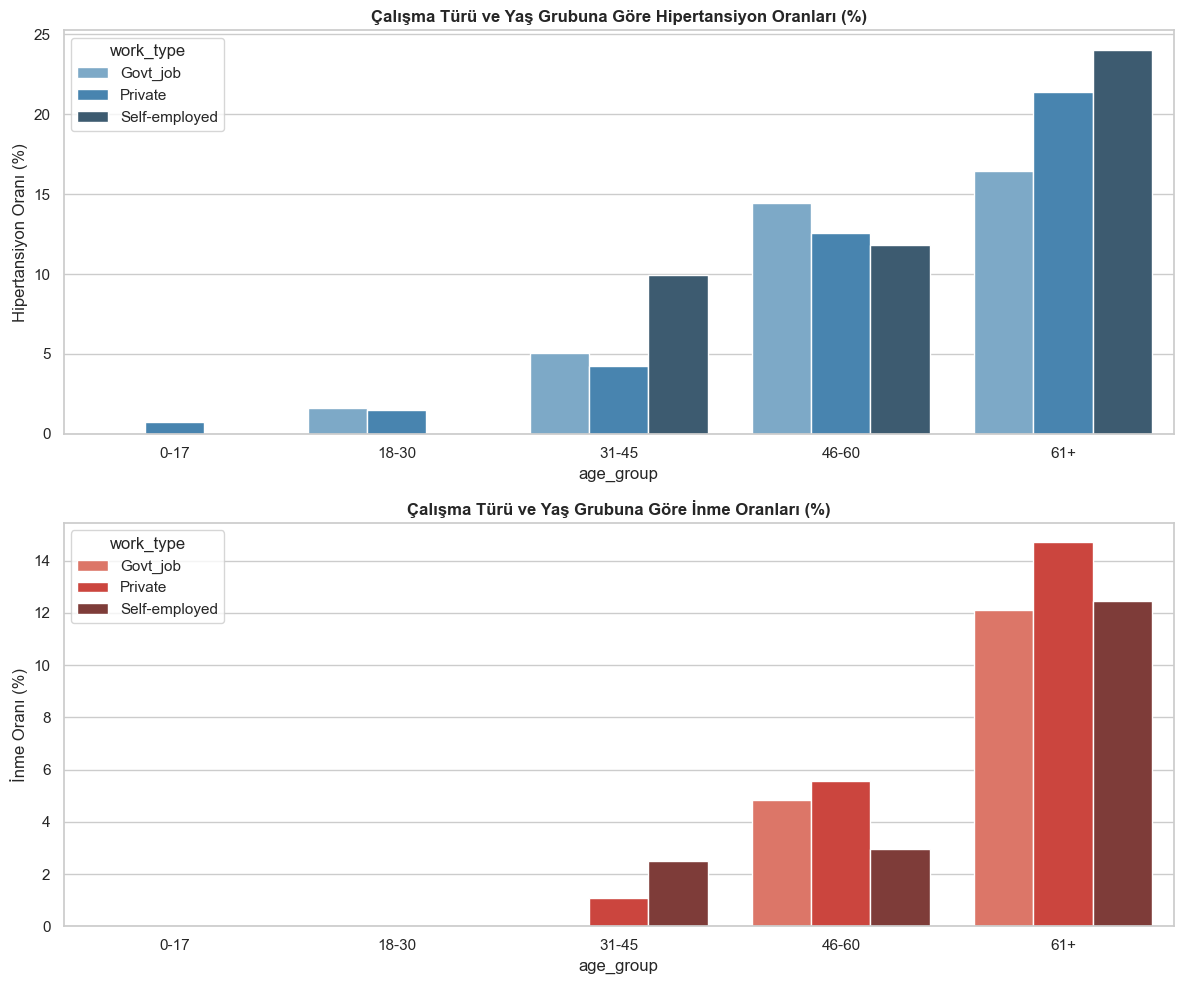

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 1, figsize=(12, 10))
sns.set_theme(style="whitegrid")

# 1. Hipertansiyon Oranları
sns.barplot(
    data=work_age_stratified,
    x="age_group",
    y="hypertension_rate_pct",
    hue="work_type",
    palette="Blues_d",
    ax=axes[0],
)
axes[0].set_title(
    "Çalışma Türü ve Yaş Grubuna Göre Hipertansiyon Oranları (%)",
    fontsize=12,
    weight="bold",
)
axes[0].set_ylabel("Hipertansiyon Oranı (%)")

# 2. İnme Oranları
sns.barplot(
    data=work_age_stratified,
    x="age_group",
    y="stroke_rate_pct",
    hue="work_type",
    palette="Reds_d",
    ax=axes[1],
)
axes[1].set_title(
    "Çalışma Türü ve Yaş Grubuna Göre İnme Oranları (%)",
    fontsize=12,
    weight="bold",
)
axes[1].set_ylabel("İnme Oranı (%)")

plt.tight_layout()
plt.show()

**Work-related Stress, Hypertension and Stroke Conclusion**

**Initial Unadjusted Observation:**
In the initial exploratory phase (unadjusted for age), a crude comparison of work_type suggested a strong association between occupational status and stroke risk. Individuals in the Self-employed category exhibited a substantially higher raw stroke rate compared to those in Private sector and Government jobs (Govt_job).

However, a closer look at the age statistics revealed a severe demographic imbalance across work types:

Elderly Clustering: Self-employed individuals are heavily skewed toward older age cohorts. In this dataset, out of 819 total Self-employed individuals, 449 are aged 61 or older (~54.8%). In contrast, senior individuals (61+) make up a much lower proportion of Private sector workers.

Stratified Re-evaluation (Age Control):
To eliminate this demographic skewness, we evaluated stroke and hypertension rates within matching age brackets:

0–30 Cohorts: Across all three employment types (Govt_job, Private, Self-employed) in the 0–17 and 18–30 age groups, stroke rates are consistently 0.00%.

31–45 Cohort: Stroke incidence begins to emerge slowly, remaining low across all sectors (Private: 1.07%, Self-employed: 2.48%, Govt_job: 0.00%).

46–60 Cohort: Stroke rates increase across all employment types, showing comparable levels between Private sector (5.55%) and Government jobs (4.82%), while Self-employed workers record 2.96%.

61+ Senior Cohort: In the senior population, stroke rates scale to double digits across all occupational groups, converging in a tight band: Government jobs at 12.09%, Self-employed at 12.47%, and Private sector at 14.71%.

Conclusion:
Stratification confirms that the seemingly elevated raw stroke risk among Self-employed individuals is a classic manifestation of age-driven confounding (Simpson's Paradox). When controlling for age, occupational type does not act as a primary driver of stroke risk; rather, the age distribution within each work category dictates the observed raw outcomes.

### <span style=" color:red"> Are males at higher risk of strokes due to work-related or lifestyle stress?
</span>

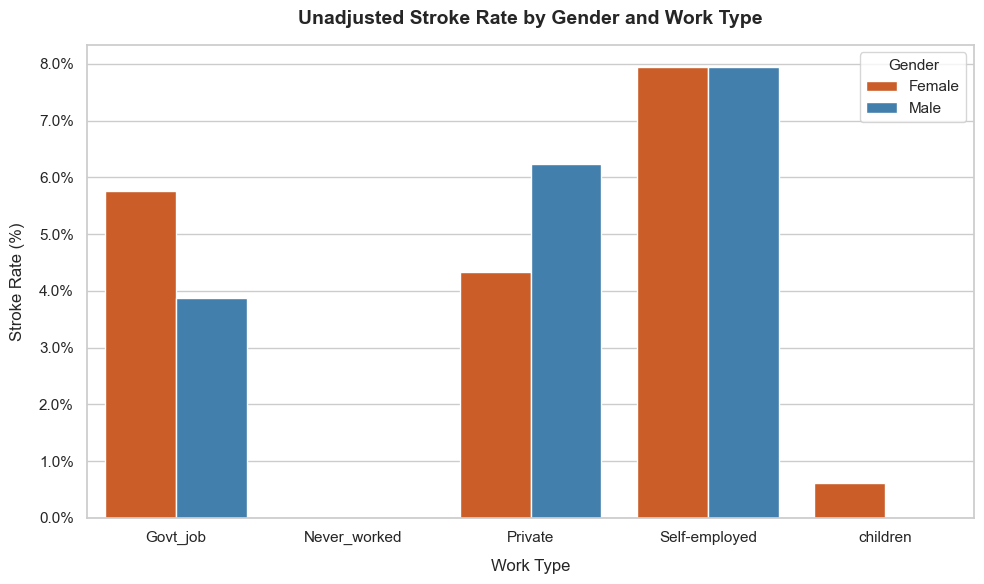

In [49]:
import matplotlib.ticker as mtick

stroke_rate = (
    df.groupby(["gender", "work_type"], observed=False)["stroke"]
    .mean()
    .reset_index()
)

custom_palette = {"Male": "#3182bd", "Female": "#e6550d"}

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=stroke_rate,
    x="work_type",
    y="stroke",
    hue="gender",
    palette=custom_palette,
)

plt.title(
    "Unadjusted Stroke Rate by Gender and Work Type",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Work Type", fontsize=12, labelpad=10)
plt.ylabel("Stroke Rate (%)", fontsize=12, labelpad=10)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.legend(title="Gender", title_fontsize="11", loc="upper right")

plt.tight_layout()
plt.show()

The bar plot directly examines the raw stroke rates across different employment categories split by gender (gender x work_type).

**Raw Observation:** While variations appear between genders in certain categories (such as Self-employed), this unadjusted plot does not account for age distribution.

**Conclusion:** As established in our age-stratified analysis, work_type serves as a proxy for age rather than job stress. Additionally, the dataset lacks direct lifestyle or psychological stress metrics. Therefore, these observed differences cannot be attributed to work-related stress, and there is no evidence to conclude that males face higher stroke risk due to occupational stress.

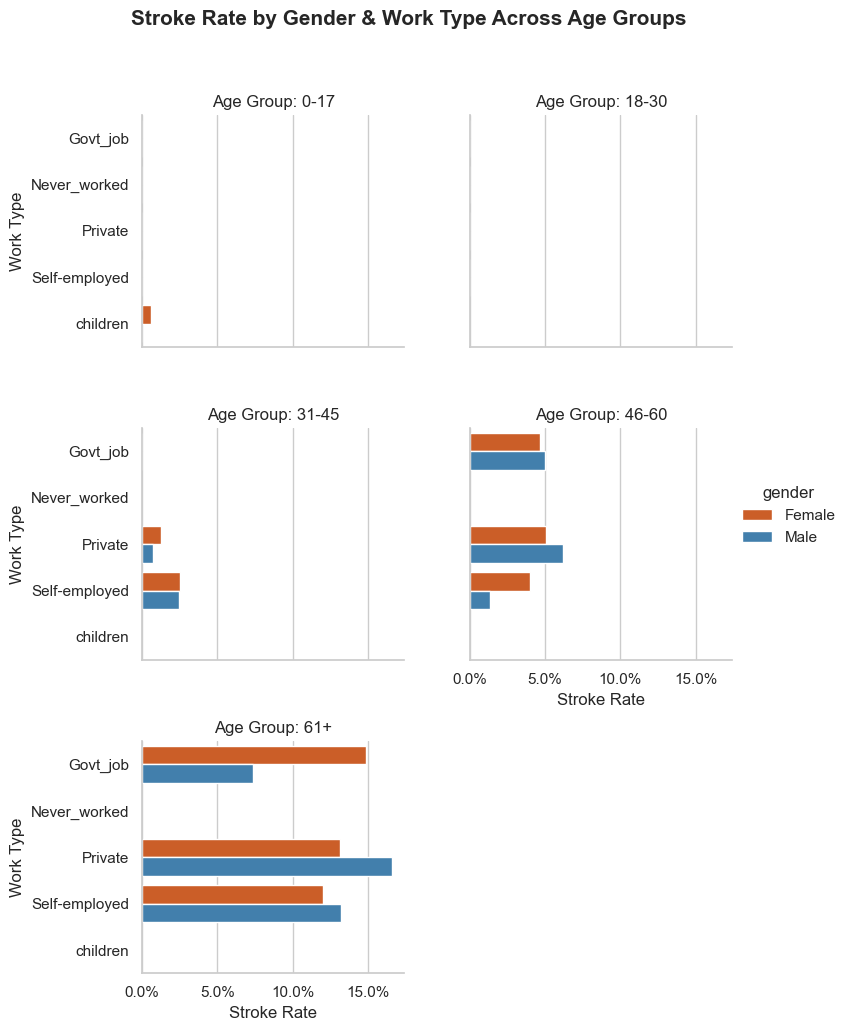

Female (Count)  Male (Count) Female (Stroke Rate)  \
age_group work_type                                                          
0-17      Govt_job                    1             5                0.00%   
          Never_worked                7            10                0.00%   
          Private                    79            55                0.00%   
          Self-employed               5             7                0.00%   
          children                  326           361                0.61%   
18-30     Govt_job                   42            21                0.00%   
          Never_worked                4             1                0.00%   
          Private                   407           204                0.00%   
          Self-employed              18            16                0.00%   
          children                    0             0                  NaN   
31-45     Govt_job                  114            64                0.00%   
          Never_worked                0             0                  NaN   
          Private                   478           271                1.26%   
          Self-employed              80            41                2.50%   
          children                    0             0                  NaN   
46-60     Govt_job                  128           100                4.69%   
          Never_worked                0             0                  NaN   
          Private                   418           339                5.02%   
          Self-employed             126            77                3.97%   
          children                    0             0                  NaN   
61+       Govt_job                  114            68               14.91%   
          Never_worked                0             0                  NaN   
          Private                   372           301               13.17%   
          Self-employed             275           174               12.00%   
          children                    0             0                  NaN   

                        Male (Stroke Rate)  
age_group work_type                         
0-17      Govt_job                   0.00%  
          Never_worked               0.00%  
          Private                    0.00%  
          Self-employed              0.00%  
          children                   0.00%  
18-30     Govt_job                   0.00%  
          Never_worked               0.00%  
          Private                    0.00%  
          Self-employed              0.00%  
          children                     NaN  
31-45     Govt_job                   0.00%  
          Never_worked                 NaN  
          Private                    0.74%  
          Self-employed              2.44%  
          children                     NaN  
46-60     Govt_job                   5.00%  
          Never_worked                 NaN  
          Private                    6.19%  
          Self-employed              1.30%  
          children                     NaN  
61+       Govt_job                   7.35%  
          Never_worked                 NaN  
          Private                   16.61%  
          Self-employed             13.22%  
          children                     NaN

In [50]:
# Work type, gender, stroke with Age

stroke_stratified = (
    df.groupby(["age_group", "work_type", "gender"], observed=False)["stroke"]
    .mean()
    .reset_index()
)

custom_palette = {"Male": "#3182bd", "Female": "#e6550d"}

sns.set_theme(style="whitegrid")
g = sns.catplot(
    data=stroke_stratified,
    y="work_type", 
    x="stroke",  
    hue="gender",
    col="age_group", 
    kind="bar",
    height=3.5,
    aspect=1.1,
    col_wrap=2, 
    palette=custom_palette,
)

g.fig.subplots_adjust(top=0.88, hspace=0.35, wspace=0.25)
g.fig.suptitle(
    "Stroke Rate by Gender & Work Type Across Age Groups",
    fontsize=15,
    fontweight="bold",
)
g.set_axis_labels("Stroke Rate", "Work Type")
g.set_titles("Age Group: {col_name}")

for ax in g.axes.flat:
    ax.xaxis.set_major_formatter(
        plt.FuncFormatter(lambda y, _: "{:.1%}".format(y))
    )

plt.show()

# Summary Pivot Table
pivot_summary = df.pivot_table(
    index=["age_group", "work_type"],
    columns="gender",
    values="stroke",
    aggfunc=["count", lambda x: f"{(x.mean() * 100):.2f}%"],
    observed=False,
)

pivot_summary.columns = [
    "Female (Count)",
    "Male (Count)",
    "Female (Stroke Rate)",
    "Male (Stroke Rate)",
]

display(pivot_summary.dropna(how="all"))

**Gender, Work-Related & Stroke Conclusion**

The age-stratified summary table evaluates stroke rates across gender and work_type combinations within standardized age brackets:

Young & Middle-Aged Groups (0–45): Across all work types (Private, Govt_job, Self-employed), stroke rates remain consistently at or near 0.00% (peaking marginally between 1.26% and 2.50% in the 31–45 range). **Occupation type exhibits no baseline risk elevation during early-to-mid working years.**

Older Age Groups (46–60 & 61+):

In the **46–60** bracket, stroke rates remain within a tight, **moderate band across all work types** (1.30% to 6.19%).

In the **61+** senior group, **stroke rates rise sharply** across the board regardless of occupation, clustering between 7.35% and 16.61%.

Gender Comparison: Within matching age and work categories, **male stroke rates show no systematic excess over female rates.** For instance, in the 46–60 Self-employed group, female stroke rate is 3.97% vs. male 1.30%, and in 61+ Govt_job, female rate is 14.91% vs. male 7.35%. Conversely, in 61+ Private employment, male rate reaches 16.61% vs. female 13.17%.

Verdict: **The numerical evidence confirms that stroke risk is driven almost entirely by aging rather than occupational status or male-specific work stress.** Observed gender variations fluctuate across cohorts without establishing a uniform male risk burden.

### <span style=" color:red"> How does the combination of risk factors amplify stroke likelihood?
</span>

In [51]:
df.head(1)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,residence_type,avg_glucose_level,bmi,smoking_status,stroke,bmi_cat,glucose_cat,age_group
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1,Obese (>=30),Diabetes (>126),61+


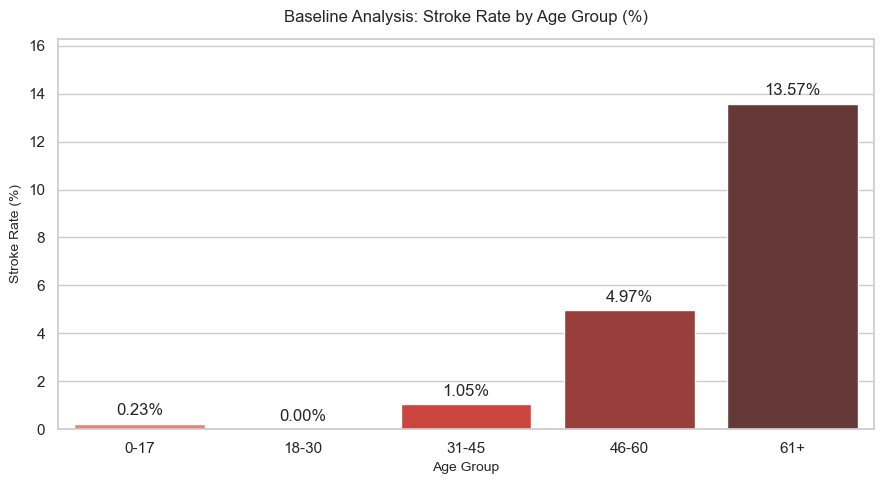

--- BASELINE AGE x STROKE RATES ---
age_group  total_people  stroke_cases  stroke_rate
     0-17           856             2     0.233645
    18-30           713             0     0.000000
    31-45          1048            11     1.049618
    46-60          1188            59     4.966330
      61+          1304           177    13.573620


In [52]:
# 1. Age Group & Stroke

age_stroke_summary = (
    df.groupby('age_group')['stroke']
    .agg(
        total_people='count',
        stroke_cases='sum',
        stroke_rate=lambda x: np.mean(x) * 100,
    )
    .reset_index()
)

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=age_stroke_summary,
    x='age_group',
    y='stroke_rate',
    palette='Reds_d',
)

plt.title(
    'Baseline Analysis: Stroke Rate by Age Group (%)', fontsize=12, pad=12
)
plt.xlabel('Age Group', fontsize=10)
plt.ylabel('Stroke Rate (%)', fontsize=10)
plt.ylim(0, max(age_stroke_summary['stroke_rate']) * 1.2)

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.2f}%',
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha='center',
        va='bottom',
        xytext=(0, 4),
        textcoords='offset points',
    )

plt.tight_layout()
plt.show()

print("--- BASELINE AGE x STROKE RATES ---")
print(age_stroke_summary.to_string(index=False))

**Baseline Analysis: Age as the Primary Confounder**

1. The Age Baseline
Before evaluating metabolic or clinical parameters, **establishing biological age as the baseline determinant** for stroke risk is essential. The univariate breakdown reveals an exponential risk trajectory across age strata:

Ages 0–30: Baseline incidence is virtually non-existent (0.00% to 0.23%).

Ages 31–45: Early risk accumulation begins at a minimal rate of 1.05%.

Ages 46–60: Stroke risk experiences a fivefold increase, reaching 4.97%.

Ages 61+: Risk escalates dramatically to an overall baseline of 13.57%—nearly triple the rate of the 46–60 cohort.

2. Methodological Justification for Stratification
**Because advanced age directly scales both overall stroke likelihood and the prevalence of secondary factors (elevated blood sugar, higher BMI, hypertension, and past smoking history), evaluating any secondary variable without controlling for age creates strong statistical illusions (Simpson's Paradox).**

Therefore, age serves as the primary stratification framework throughout this entire report to isolate true risk drivers from age-induced noise.

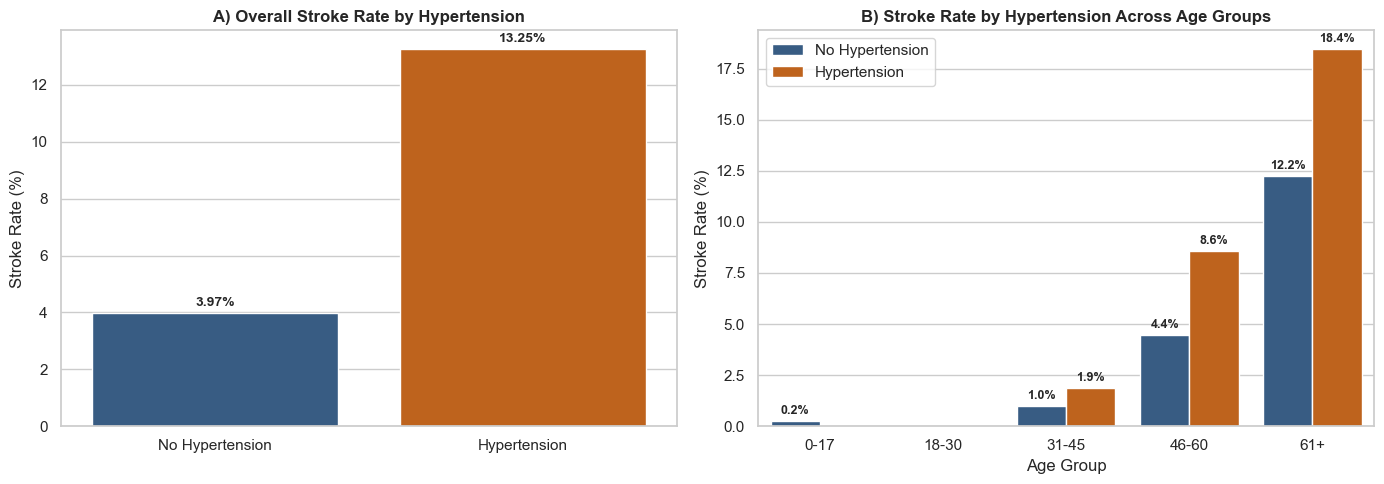

In [53]:
# 1. hypertension rate without age group.

ht_raw = (
    df.groupby("hypertension", observed=False)["stroke"].mean().reset_index()
)
ht_raw["stroke_pct"] = ht_raw["stroke"] * 100
ht_raw["ht_label"] = ht_raw["hypertension"].map(
    {0: "No Hypertension", 1: "Hypertension"}
)

# 2. hypertension rate with age group.

ht_age = (
    df.groupby(["age_group", "hypertension"], observed=False)["stroke"]
    .mean()
    .reset_index()
)
ht_age["stroke_pct"] = ht_age["stroke"] * 100
ht_age["ht_label"] = ht_age["hypertension"].map(
    {0: "No Hypertension", 1: "Hypertension"}
)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.set_theme(style="whitegrid")

ax1 = sns.barplot(
    data=ht_raw,
    x="ht_label",
    y="stroke_pct",
    palette=["#2b5c8f", "#d95f02"],
    ax=axes[0],
    hue="ht_label",
    legend=False,
)
axes[0].set_title(
    "A) Overall Stroke Rate by Hypertension", fontsize=12, weight="bold"
)
axes[0].set_ylabel("Stroke Rate (%)")
axes[0].set_xlabel("")

for p in ax1.patches:
    h = p.get_height()
    if h > 0:
        ax1.annotate(
            f"{h:.2f}%",
            (p.get_x() + p.get_width() / 2.0, h),
            ha="center",
            va="bottom",
            fontsize=10,
            weight="bold",
            xytext=(0, 3),
            textcoords="offset points",
        )

ax2 = sns.barplot(
    data=ht_age,
    x="age_group",
    y="stroke_pct",
    hue="ht_label",
    palette=["#2b5c8f", "#d95f02"],
    ax=axes[1],
)
axes[1].set_title(
    "B) Stroke Rate by Hypertension Across Age Groups",
    fontsize=12,
    weight="bold",
)
axes[1].set_ylabel("Stroke Rate (%)")
axes[1].set_xlabel("Age Group")
axes[1].legend(title="")

for p in ax2.patches:
    h = p.get_height()
    if h > 0:
        ax2.annotate(
            f"{h:.1f}%",
            (p.get_x() + p.get_width() / 2.0, h),
            ha="center",
            va="bottom",
            fontsize=9,
            weight="bold",
            xytext=(0, 3),
            textcoords="offset points",
        )

plt.tight_layout()
plt.show()

In [54]:
# 1. Hypertension Stroke rate table without Age Group. 

ht_raw_pivot = df.groupby("hypertension", observed=False)["stroke"].agg(
    Count="count",
    Stroke_Cases="sum",
    Stroke_Rate=lambda x: f"{(x.mean() * 100):.2f}%",
).reset_index()

ht_raw_pivot["hypertension"] = ht_raw_pivot["hypertension"].map(
    {0: "No Hypertension", 1: "Hypertension"}
)

display(ht_raw_pivot)

,hypertension,Count,Stroke_Cases,Stroke_Rate
0,No Hypertension,4611,183,3.97%
1,Hypertension,498,66,13.25%


In [55]:
# 2. Yaş Kırılımlı Hipertansiyon & İnme Tablosu
ht_age_pivot = df.pivot_table(
    index="age_group",
    columns="hypertension",
    values="stroke",
    aggfunc=["count", lambda x: f"{(x.mean() * 100):.2f}%"],
    observed=False,
)

ht_age_pivot.columns = [
    "No HT (Count)",
    "HT (Count)",
    "No HT (Stroke Rate)",
    "HT (Stroke Rate)",
]

display(ht_age_pivot)

,No HT (Count),HT (Count),No HT (Stroke Rate),HT (Stroke Rate)
age_group,,,,
0-17,855,1,0.23%,0.00%
18-30,703,10,0.00%,0.00%
31-45,995,53,1.01%,1.89%
46-60,1036,152,4.44%,8.55%
61+,1022,282,12.23%,18.44%


**Hypertension & Stroke Conclusion**

Overall Results (Unadjusted): People with hypertension have a 13.25% stroke rate compared to 3.97% for those without it. This looks like a 3x risk increase at first glance.

Age-Stratified Results:

Ages 0–30: Stroke risk is virtually 0.00%.

Ages 31–45: Risk stays very low, moving slightly from 1.01% to 1.89%.

Ages 46–60: Hypertension nearly doubles the stroke risk from 4.44% to 8.55%.

Ages 61+: Stroke risk is naturally higher due to age, but hypertension pushes it further from 12.23% to 18.44%.

Verdict: **Aging raises overall risk, but hypertension acts as a clear risk multiplier—roughly doubling the chance of a stroke after age 45.**

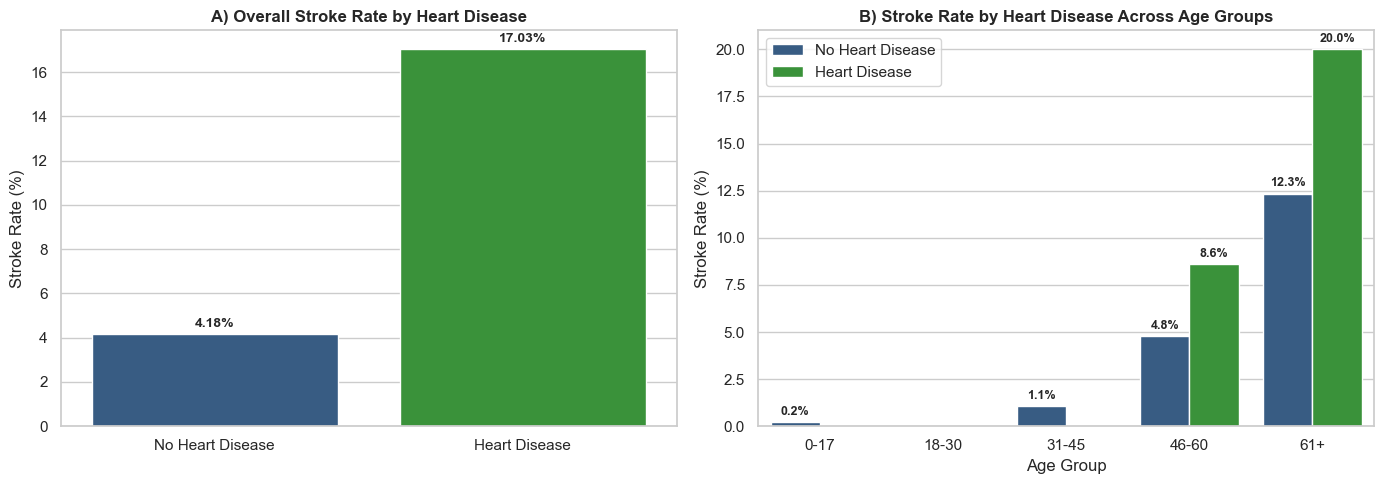

In [56]:
# 1. heart_disease and stroke rate without age gorup.

hd_raw = (
    df.groupby("heart_disease", observed=False)["stroke"].mean().reset_index()
)
hd_raw["stroke_pct"] = hd_raw["stroke"] * 100
hd_raw["hd_label"] = hd_raw["heart_disease"].map(
    {0: "No Heart Disease", 1: "Heart Disease"}
)

# 2. heart_disease and stroke rate with age gorup.

hd_age = (
    df.groupby(["age_group", "heart_disease"], observed=False)["stroke"]
    .mean()
    .reset_index()
)
hd_age["stroke_pct"] = hd_age["stroke"] * 100
hd_age["hd_label"] = hd_age["heart_disease"].map(
    {0: "No Heart Disease", 1: "Heart Disease"}
)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.set_theme(style="whitegrid")

ax1 = sns.barplot(
    data=hd_raw,
    x="hd_label",
    y="stroke_pct",
    palette=["#2b5c8f", "#2ca02c"],
    ax=axes[0],
    hue="hd_label",
    legend=False,
)
axes[0].set_title(
    "A) Overall Stroke Rate by Heart Disease", fontsize=12, weight="bold"
)
axes[0].set_ylabel("Stroke Rate (%)")
axes[0].set_xlabel("")

for p in ax1.patches:
    h = p.get_height()
    if h > 0:
        ax1.annotate(
            f"{h:.2f}%",
            (p.get_x() + p.get_width() / 2.0, h),
            ha="center",
            va="bottom",
            fontsize=10,
            weight="bold",
            xytext=(0, 3),
            textcoords="offset points",
        )

ax2 = sns.barplot(
    data=hd_age,
    x="age_group",
    y="stroke_pct",
    hue="hd_label",
    palette=["#2b5c8f", "#2ca02c"],
    ax=axes[1],
)
axes[2] if False else None  # Safety check
axes[1].set_title(
    "B) Stroke Rate by Heart Disease Across Age Groups",
    fontsize=12,
    weight="bold",
)
axes[1].set_ylabel("Stroke Rate (%)")
axes[1].set_xlabel("Age Group")
axes[1].legend(title="")

for p in ax2.patches:
    h = p.get_height()
    if h > 0:
        ax2.annotate(
            f"{h:.1f}%",
            (p.get_x() + p.get_width() / 2.0, h),
            ha="center",
            va="bottom",
            fontsize=9,
            weight="bold",
            xytext=(0, 3),
            textcoords="offset points",
        )

plt.tight_layout()
plt.show()

In [57]:
# 1. Heart_disease and Stroke Rate table without age group.

hd_raw_pivot = df.groupby("heart_disease", observed=False)["stroke"].agg(
    Count="count",
    Stroke_Cases="sum",
    Stroke_Rate=lambda x: f"{(x.mean() * 100):.2f}%",
).reset_index()

hd_raw_pivot["heart_disease"] = hd_raw_pivot["heart_disease"].map(
    {0: "No Heart Disease", 1: "Heart Disease"}
)

display(hd_raw_pivot)

,heart_disease,Count,Stroke_Cases,Stroke_Rate
0,No Heart Disease,4833,202,4.18%
1,Heart Disease,276,47,17.03%


In [58]:
# 2. Heart_disease and Stroke Rate table with age group.

hd_age_pivot = df.pivot_table(
    index="age_group",
    columns="heart_disease",
    values="stroke",
    aggfunc=["count", lambda x: f"{(x.mean() * 100):.2f}%"],
    observed=False,
)

hd_age_pivot.columns = [
    "No HD (Count)",
    "HD (Count)",
    "No HD (Stroke Rate)",
    "HD (Stroke Rate)",
]

display(hd_age_pivot)

,No HD (Count),HD (Count),No HD (Stroke Rate),HD (Stroke Rate)
age_group,,,,
0-17,855,1,0.23%,0.00%
18-30,712,1,0.00%,0.00%
31-45,1042,6,1.06%,0.00%
46-60,1130,58,4.78%,8.62%
61+,1094,210,12.34%,20.00%


**Heart Disease & Stroke Risk**

Overall Results (Unadjusted): Individuals with heart disease display a stroke rate of 17.03% compared to 4.18% in those without, presenting a raw ~4x relative risk surge.

Age-Stratified Results:

Ages 0–45: Heart disease prevalence is minimal, and stroke incidence remains at 0.00% regardless of cardiac condition.

Ages 46–60: Heart disease nearly doubles the stroke risk from 4.78% to 8.62%.

Ages 61+: Baseline stroke risk is 12.34%, but cardiac conditions elevate it significantly to 20.00%.

Verdict: **Similar to hypertension, heart disease does not drive stroke risk in younger years. Past age 45, however, it operates as a direct risk multiplier, roughly doubling stroke likelihood in mature and senior cohorts.**

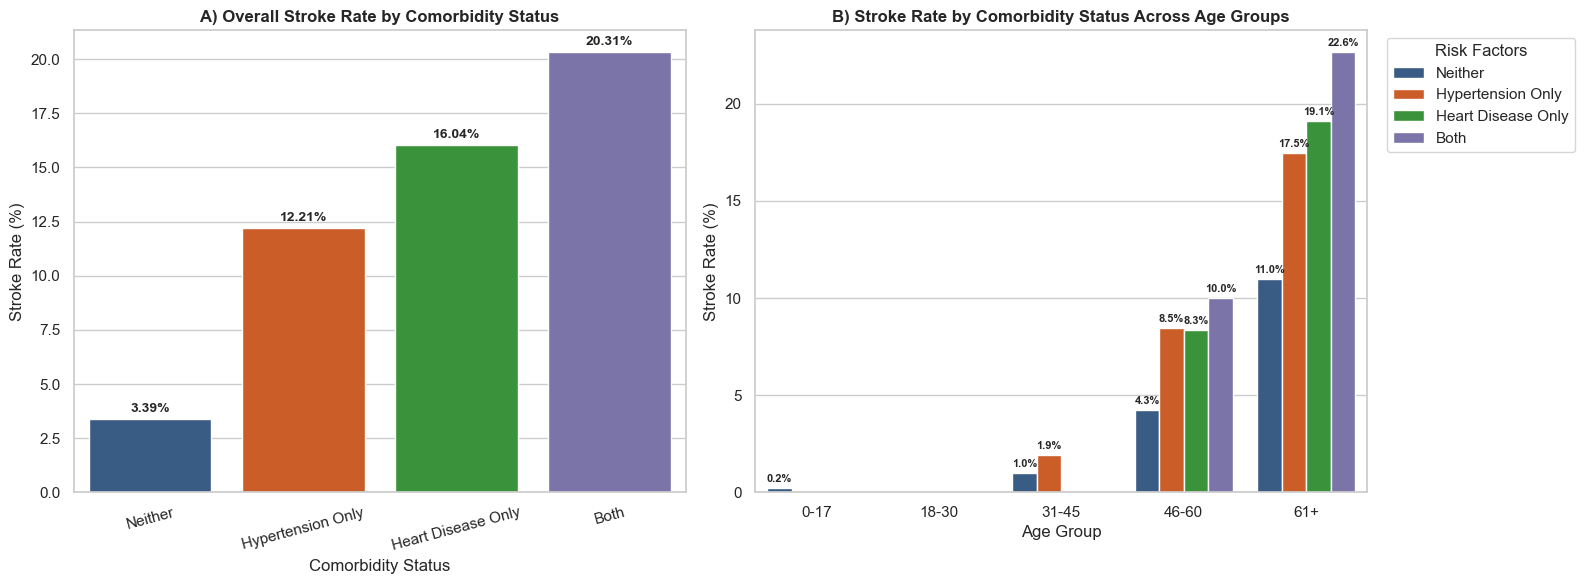

In [59]:
# 1. Creating a Combined Risk Factor Variable;

conditions = [
    (df["hypertension"] == 0) & (df["heart_disease"] == 0),
    (df["hypertension"] == 1) & (df["heart_disease"] == 0),
    (df["hypertension"] == 0) & (df["heart_disease"] == 1),
    (df["hypertension"] == 1) & (df["heart_disease"] == 1),
]

choices = ["Neither", "Hypertension Only", "Heart Disease Only", "Both"]

df["comorbidity_status"] = np.select(conditions, choices, default="Neither")

# 1 . Fixing category order

risk_order = ["Neither", "Hypertension Only", "Heart Disease Only", "Both"]
df["comorbidity_status"] = pd.Categorical(
    df["comorbidity_status"], categories=risk_order, ordered=True
)

# 2. Raw Combined Rates;

combo_raw = (
    df.groupby("comorbidity_status", observed=False)["stroke"]
    .mean()
    .reset_index()
)
combo_raw["stroke_pct"] = combo_raw["stroke"] * 100

# 3.  Combined Rates with Age Group;

combo_age = (
    df.groupby(["age_group", "comorbidity_status"], observed=False)["stroke"]
    .mean()
    .reset_index()
)
combo_age["stroke_pct"] = combo_age["stroke"] * 100

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="whitegrid")
custom_palette = ["#2b5c8f", "#e6550d", "#2ca02c", "#756bb1"]

# Panel A: Raw Combined Rates
ax1 = sns.barplot(
    data=combo_raw,
    x="comorbidity_status",
    y="stroke_pct",
    palette=custom_palette,
    ax=axes[0],
    hue="comorbidity_status",
    legend=False,
)
axes[0].set_title(
    "A) Overall Stroke Rate by Comorbidity Status", fontsize=12, weight="bold"
)
axes[0].set_ylabel("Stroke Rate (%)")
axes[0].set_xlabel("Comorbidity Status")
axes[0].tick_params(axis="x", rotation=15)

for p in ax1.patches:
    h = p.get_height()
    if h > 0:
        ax1.annotate(
            f"{h:.2f}%",
            (p.get_x() + p.get_width() / 2.0, h),
            ha="center",
            va="bottom",
            fontsize=10,
            weight="bold",
            xytext=(0, 3),
            textcoords="offset points",
        )

# Panel B: Combined Rates with Age Group

ax2 = sns.barplot(
    data=combo_age,
    x="age_group",
    y="stroke_pct",
    hue="comorbidity_status",
    palette=custom_palette,
    ax=axes[1],
)
axes[1].set_title(
    "B) Stroke Rate by Comorbidity Status Across Age Groups",
    fontsize=12,
    weight="bold",
)
axes[1].set_ylabel("Stroke Rate (%)")
axes[1].set_xlabel("Age Group")
axes[1].legend(title="Risk Factors", bbox_to_anchor=(1.02, 1), loc="upper left")

for p in ax2.patches:
    h = p.get_height()
    if h > 0:
        ax2.annotate(
            f"{h:.1f}%",
            (p.get_x() + p.get_width() / 2.0, h),
            ha="center",
            va="bottom",
            fontsize=8,
            weight="bold",
            xytext=(0, 3),
            textcoords="offset points",
        )

plt.tight_layout()
plt.show()

In [60]:
# 1. Combined Rates without Age Group

combo_raw_pivot = df.groupby("comorbidity_status", observed=False)["stroke"].agg(
    Count="count",
    Stroke_Cases="sum",
    Stroke_Rate=lambda x: f"{(x.mean() * 100):.2f}%",
).reset_index()

display(combo_raw_pivot)

,comorbidity_status,Count,Stroke_Cases,Stroke_Rate
0,Neither,4399,149,3.39%
1,Hypertension Only,434,53,12.21%
2,Heart Disease Only,212,34,16.04%
3,Both,64,13,20.31%


In [61]:
# 2. Combined Rates without Age Group

combo_age_pivot = df.pivot_table(
    index="age_group",
    columns="comorbidity_status",
    values="stroke",
    aggfunc=["count", lambda x: f"{(x.mean() * 100):.2f}%"],
    observed=False,
)

# Formatting column names

combo_age_pivot.columns = [
    "Neither (Count)",
    "HT Only (Count)",
    "HD Only (Count)",
    "Both (Count)",
    "Neither (Stroke Rate)",
    "HT Only (Stroke Rate)",
    "HD Only (Stroke Rate)",
    "Both (Stroke Rate)",
]

display(combo_age_pivot)

,Neither (Count),HT Only (Count),HD Only (Count),Both (Count),Neither (Stroke Rate),HT Only (Stroke Rate),HD Only (Stroke Rate),Both (Stroke Rate)
age_group,,,,,,,,
0-17,854,1,1,0,0.23%,0.00%,0.00%,NaN
18-30,702,10,1,0,0.00%,0.00%,0.00%,NaN
31-45,990,52,5,1,1.01%,1.92%,0.00%,0.00%
46-60,988,142,48,10,4.25%,8.45%,8.33%,10.00%
61+,865,229,157,53,10.98%,17.47%,19.11%,22.64%


**Comorbidity & Age Group Risk Analysis**

Young Cohorts (0–45 Years): Stroke incidence remains negligible ($\%0.00 - \%1.92$) across all sub-groups under age 45, regardless of underlying conditions. No combined comorbidity cases exist below age 30 (NaN).

Mid-Life Activation (46–60 Years): Clinical risk activates after age 45. Baseline stroke rate is $\%4.25$ for healthy individuals. Having either Hypertension ($\%8.45$) or Heart Disease ($\%8.33$) approximately doubles the stroke rate, while having both elevates it to $\%10.00$.

Older Cohorts & Compounding Risk (61+ Years): Baseline stroke rate jumps to $\%10.98$ past age 60. Individual conditions elevate stroke rates to $\%17.47$ (HT) and $\%19.11$ (HD). The presence of both conditions drives stroke incidence to $\%22.64\%$ (~1 in 4 patients).

Modeling Decision: The predictive impact of comorbidities is negligible below age 45 and highly non-linear post-45. This mathematically justifies designing an age-interaction term alongside the Cumulative Risk Score during Feature Engineering.

In [62]:
df["glucose_cat"].unique()

['Diabetes (>126)', 'Prediabetes (100-125)', 'Normal (<100)']
Categories (3, object): ['Normal (<100)' < 'Prediabetes (100-125)' < 'Diabetes (>126)']

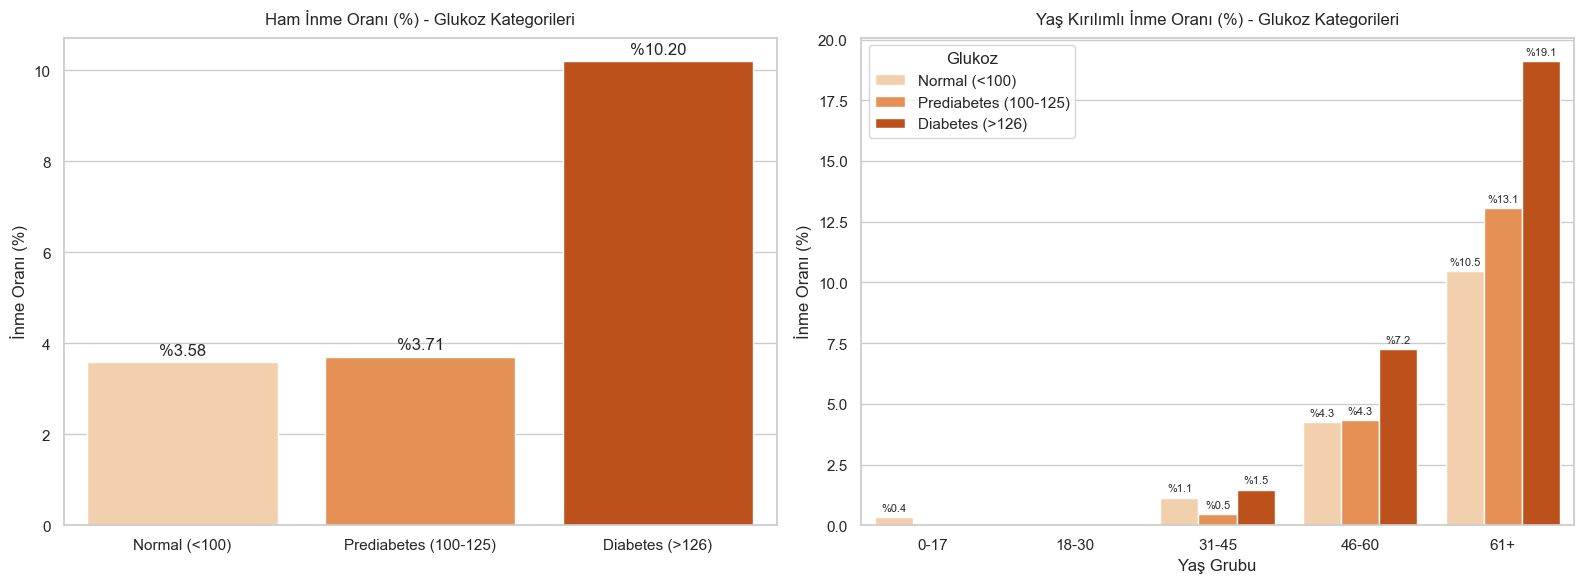

In [63]:
df_glc_age = (
    df.groupby(["age_group", "glucose_cat"], observed=False)["stroke"]
    .mean()
    .mul(100)
    .reset_index()
)
df_glc_raw = (
    df.groupby("glucose_cat", observed=False)["stroke"]
    .mean()
    .mul(100)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Without age group

sns.barplot(
    data=df_glc_raw,
    x="glucose_cat",
    y="stroke",
    palette="Oranges",
    ax=axes[0],
)
axes[0].set_title("Ham İnme Oranı (%) - Glukoz Kategorileri", fontsize=12, pad=10)
axes[0].set_ylabel("İnme Oranı (%)")
axes[0].set_xlabel("")
for p in axes[0].patches:
    axes[0].annotate(
        f"%{p.get_height():.2f}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="bottom",
        xytext=(0, 3),
        textcoords="offset points",
    )

# 2. with age group

sns.barplot(
    data=df_glc_age,
    x="age_group",
    y="stroke",
    hue="glucose_cat",
    palette="Oranges",
    ax=axes[1],
)
axes[1].set_title(
    "Yaş Kırılımlı İnme Oranı (%) - Glukoz Kategorileri", fontsize=12, pad=10
)
axes[1].set_ylabel("İnme Oranı (%)")
axes[1].set_xlabel("Yaş Grubu")
axes[1].legend(title="Glukoz")
for p in axes[1].patches:
    height = p.get_height()
    if height > 0:
        axes[1].annotate(
            f"%{height:.1f}",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="bottom",
            xytext=(0, 3),
            textcoords="offset points",
            fontsize=8,
        )

plt.tight_layout()
plt.show()

In [64]:
# 1. Glucose and Stroke without age group

glc_raw_pivot = df.groupby("glucose_cat", observed=False)["stroke"].agg(
    Count="count",
    Stroke_Cases="sum",
    Stroke_Rate=lambda x: f"{(x.mean() * 100):.2f}%",
).reset_index()

# 2. Glucose and Stroke with age group

glc_age_pivot = df.pivot_table(
    index="age_group",
    columns="glucose_cat",
    values="stroke",
    aggfunc=["count", lambda x: f"{(x.mean() * 100):.2f}%"],
    observed=False,
)

glc_age_pivot.columns = [
    "Normal (Count)",
    "Prediabetes (Count)",
    "Diabetes (Count)",
    "Normal (Stroke Rate)",
    "Prediabetes (Stroke Rate)",
    "Diabetes (Stroke Rate)",
]

display(glc_raw_pivot)
display(glc_age_pivot)

,glucose_cat,Count,Stroke_Cases,Stroke_Rate
0,Normal (<100),3131,112,3.58%
1,Prediabetes (100-125),998,37,3.71%
2,Diabetes (>126),980,100,10.20%


,Normal (Count),Prediabetes (Count),Diabetes (Count),Normal (Stroke Rate),Prediabetes (Stroke Rate),Diabetes (Stroke Rate)
age_group,,,,,,
0-17,568,200,88,0.35%,0.00%,0.00%
18-30,484,157,72,0.00%,0.00%,0.00%
31-45,701,211,136,1.14%,0.47%,1.47%
46-60,681,231,276,4.26%,4.33%,7.25%
61+,697,199,408,10.47%,13.07%,19.12%


**Glucose & Stroke Rate**

Unadjusted (Raw) Findings: Stroke rates remain nearly identical between Normal (3.58%) and Prediabetes (3.71%) categories, but surge to 10.20% in the Diabetes group (a ~3x increase), masking the underlying age-dependent progression.

Age-Stratified Findings:

Ages 0–30: Stroke risk is non-existent to negligible (0.00%–0.35%).

Ages 31–45: Rates remain minimal across all glucose levels (0.47%–1.47%) with no clear linear pattern.

Ages 46–60: Normal (4.26%) and Prediabetes (4.33%) yield nearly identical risks, whereas Diabetes elevates stroke occurrence to 7.25% (~1.7x increase).

Ages 61+: Age acts as the primary risk foundation while elevated glucose demonstrates a clear stepwise increase: Normal (10.47%), Prediabetes (13.07%), and Diabetes (19.12%).

Summary: **Aging provides the baseline risk level for stroke.** While glucose levels have minimal impact before age 45, **Diabetes almost doubles stroke incidence between ages 46–60. In the 61+ cohort, glucose demonstrates a continuous risk-multiplying effect, where even Prediabetes elevates stroke probability beyond the age-adjusted baseline.**

In [65]:
df["bmi_cat"].unique()

['Obese (>=30)', 'Overweight (25-29.9)', 'Normal (18.5-24.9)', 'Underweight (<18.5)']
Categories (4, object): ['Underweight (<18.5)' < 'Normal (18.5-24.9)' < 'Overweight (25-29.9)' < 'Obese (>=30)']

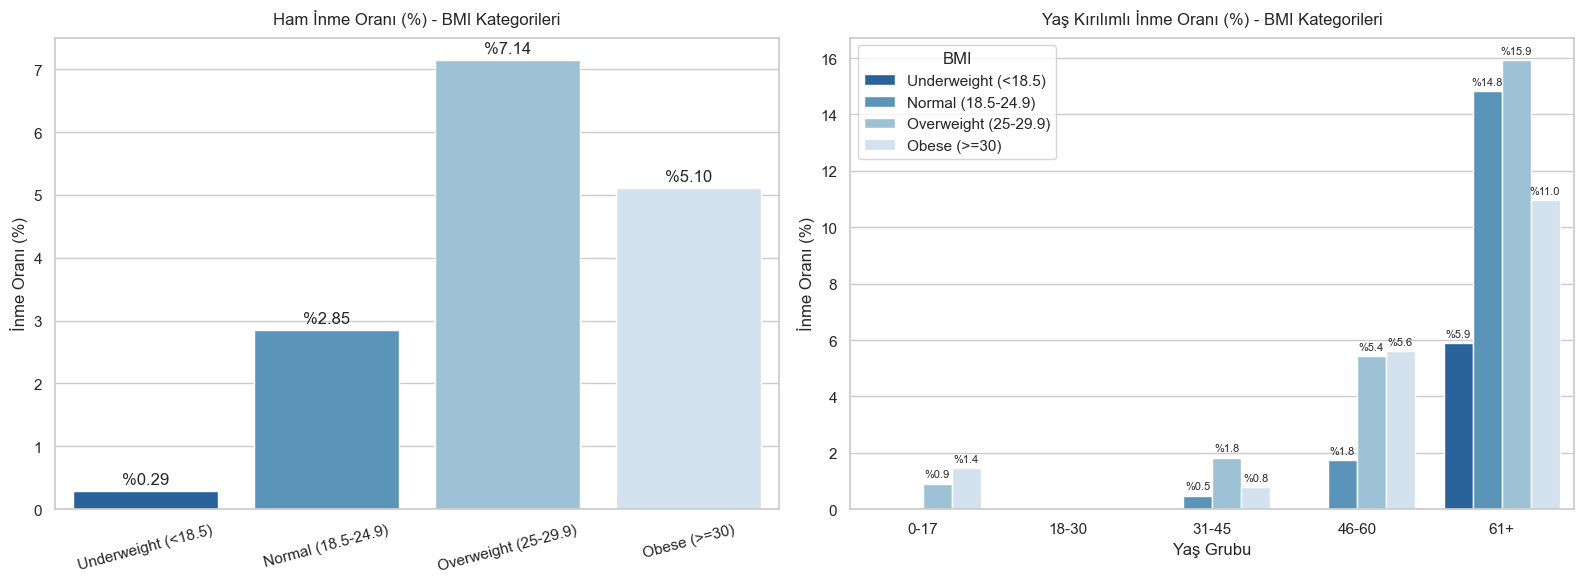

In [66]:
df_bmi_age = (
    df.groupby(["age_group", "bmi_cat"], observed=False)["stroke"]
    .mean()
    .mul(100)
    .reset_index()
)
df_bmi_raw = (
    df.groupby("bmi_cat", observed=False)["stroke"]
    .mean()
    .mul(100)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Without Age group

sns.barplot(
    data=df_bmi_raw,
    x="bmi_cat",
    y="stroke",
    palette="Blues_r",
    ax=axes[0],
)
axes[0].set_title("Ham İnme Oranı (%) - BMI Kategorileri", fontsize=12, pad=10)
axes[0].set_ylabel("İnme Oranı (%)")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=15)
for p in axes[0].patches:
    axes[0].annotate(
        f"%{p.get_height():.2f}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="bottom",
        xytext=(0, 3),
        textcoords="offset points",
    )

# 2. With Age Group;

sns.barplot(
    data=df_bmi_age,
    x="age_group",
    y="stroke",
    hue="bmi_cat",
    palette="Blues_r",
    ax=axes[1],
)
axes[1].set_title(
    "Yaş Kırılımlı İnme Oranı (%) - BMI Kategorileri", fontsize=12, pad=10
)
axes[1].set_ylabel("İnme Oranı (%)")
axes[1].set_xlabel("Yaş Grubu")
axes[1].legend(title="BMI")
for p in axes[1].patches:
    height = p.get_height()
    if height > 0:
        axes[1].annotate(
            f"%{height:.1f}",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="bottom",
            xytext=(0, 3),
            textcoords="offset points",
            fontsize=8,
        )

plt.tight_layout()
plt.show()

In [67]:
# 1. BMI & Stroke without age group;

bmi_raw_pivot = (
    df.groupby("bmi_cat", observed=False)["stroke"]
    .agg(
        Count="count",
        Stroke_Cases="sum",
        Stroke_Rate=lambda x: f"{(x.mean() * 100):.2f}%",
    )
    .reset_index()
)

# 2. BMI & Stroke with age group;

bmi_age_pivot = df.pivot_table(
    index="age_group",
    columns="bmi_cat",
    values="stroke",
    aggfunc=["count", lambda x: f"{(x.mean() * 100):.2f}%"],
    observed=False,
)

# Formatting column names;

bmi_age_pivot.columns = [
    "Obese (Count)",
    "Overweight (Count)",
    "Normal (Count)",
    "Underweight (Count)",
    "Obese (Stroke Rate)",
    "Overweight (Stroke Rate)",
    "Normal (Stroke Rate)",
    "Underweight (Stroke Rate)",
]

display(bmi_raw_pivot)
display(bmi_age_pivot)

,bmi_cat,Count,Stroke_Cases,Stroke_Rate
0,Underweight (<18.5),349,1,0.29%
1,Normal (18.5-24.9),1230,35,2.85%
2,Overweight (25-29.9),1610,115,7.14%
3,Obese (>=30),1920,98,5.10%


,Obese (Count),Overweight (Count),Normal (Count),Underweight (Count),Obese (Stroke Rate),Overweight (Stroke Rate),Normal (Stroke Rate),Underweight (Stroke Rate)
age_group,,,,,,,,
0-17,309,368,110,69,0.00%,0.00%,0.91%,1.45%
18-30,12,275,226,200,0.00%,0.00%,0.00%,0.00%
31-45,6,207,328,507,0.00%,0.48%,1.83%,0.79%
46-60,5,171,406,606,0.00%,1.75%,5.42%,5.61%
61+,17,209,540,538,5.88%,14.83%,15.93%,10.97%


**Body Mass Index (BMI) & Stroke**

Baseline Observation (Unadjusted):
Evaluating BMI categories without controlling for age suggests an apparent elevated risk in higher weight classes:

Underweight (<18.5): 0.29%

Normal Weight (18.5–24.9): 2.85%

Overweight (25–29.9): 7.14% (~2.5x raw increase vs Normal)

Obese (≥30): 5.10%

Age-Stratified Findings:
Stratifying across age cohorts dissolves the linear pattern and exposes a non-linear risk distribution:

Ages 0–30: Stroke rates remain virtually non-existent (0.00%–1.45%) across all BMI groups.

Ages 31–45: Incidence stays minimal (0.00%–1.83%) without clear risk clustering.

Ages 46–60: Normal Weight (5.61%) and Overweight (5.42%) cohorts display nearly identical stroke rates.

Ages 61+: Normal Weight (15.93%) and Overweight (14.83%) cohorts maintain closely aligned stroke probabilities, whereas the Obese cohort records a lower rate at 5.88%.

Verdict: The empirical data demonstrates that BMI does not act as a monotonic or linear risk driver for stroke. Across middle-aged cohorts (46–60), stroke rates remain stable between Normal and Overweight categories. In the senior cohort (61+), stroke incidence drops in the Obese category compared to Normal and Overweight groups. **Based strictly on the observed figures, BMI alone does not display a simple proportional relationship with stroke risk.**

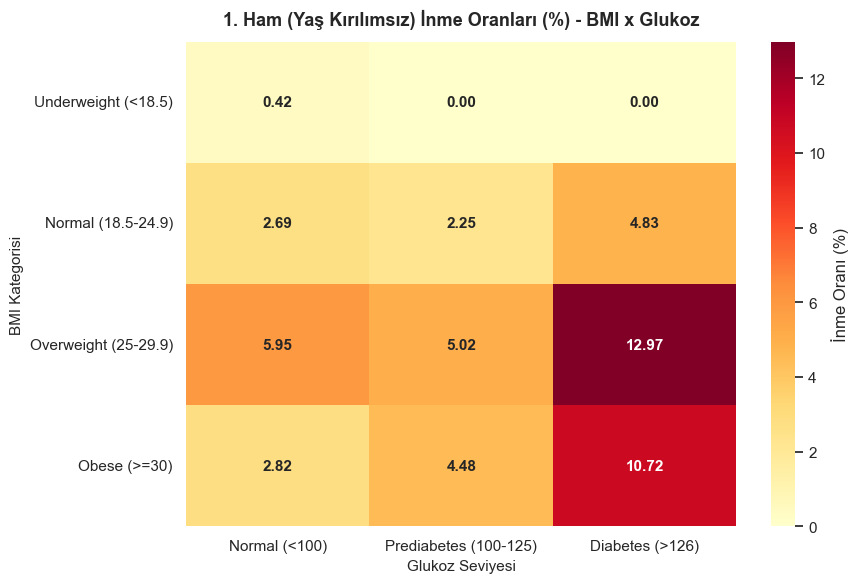

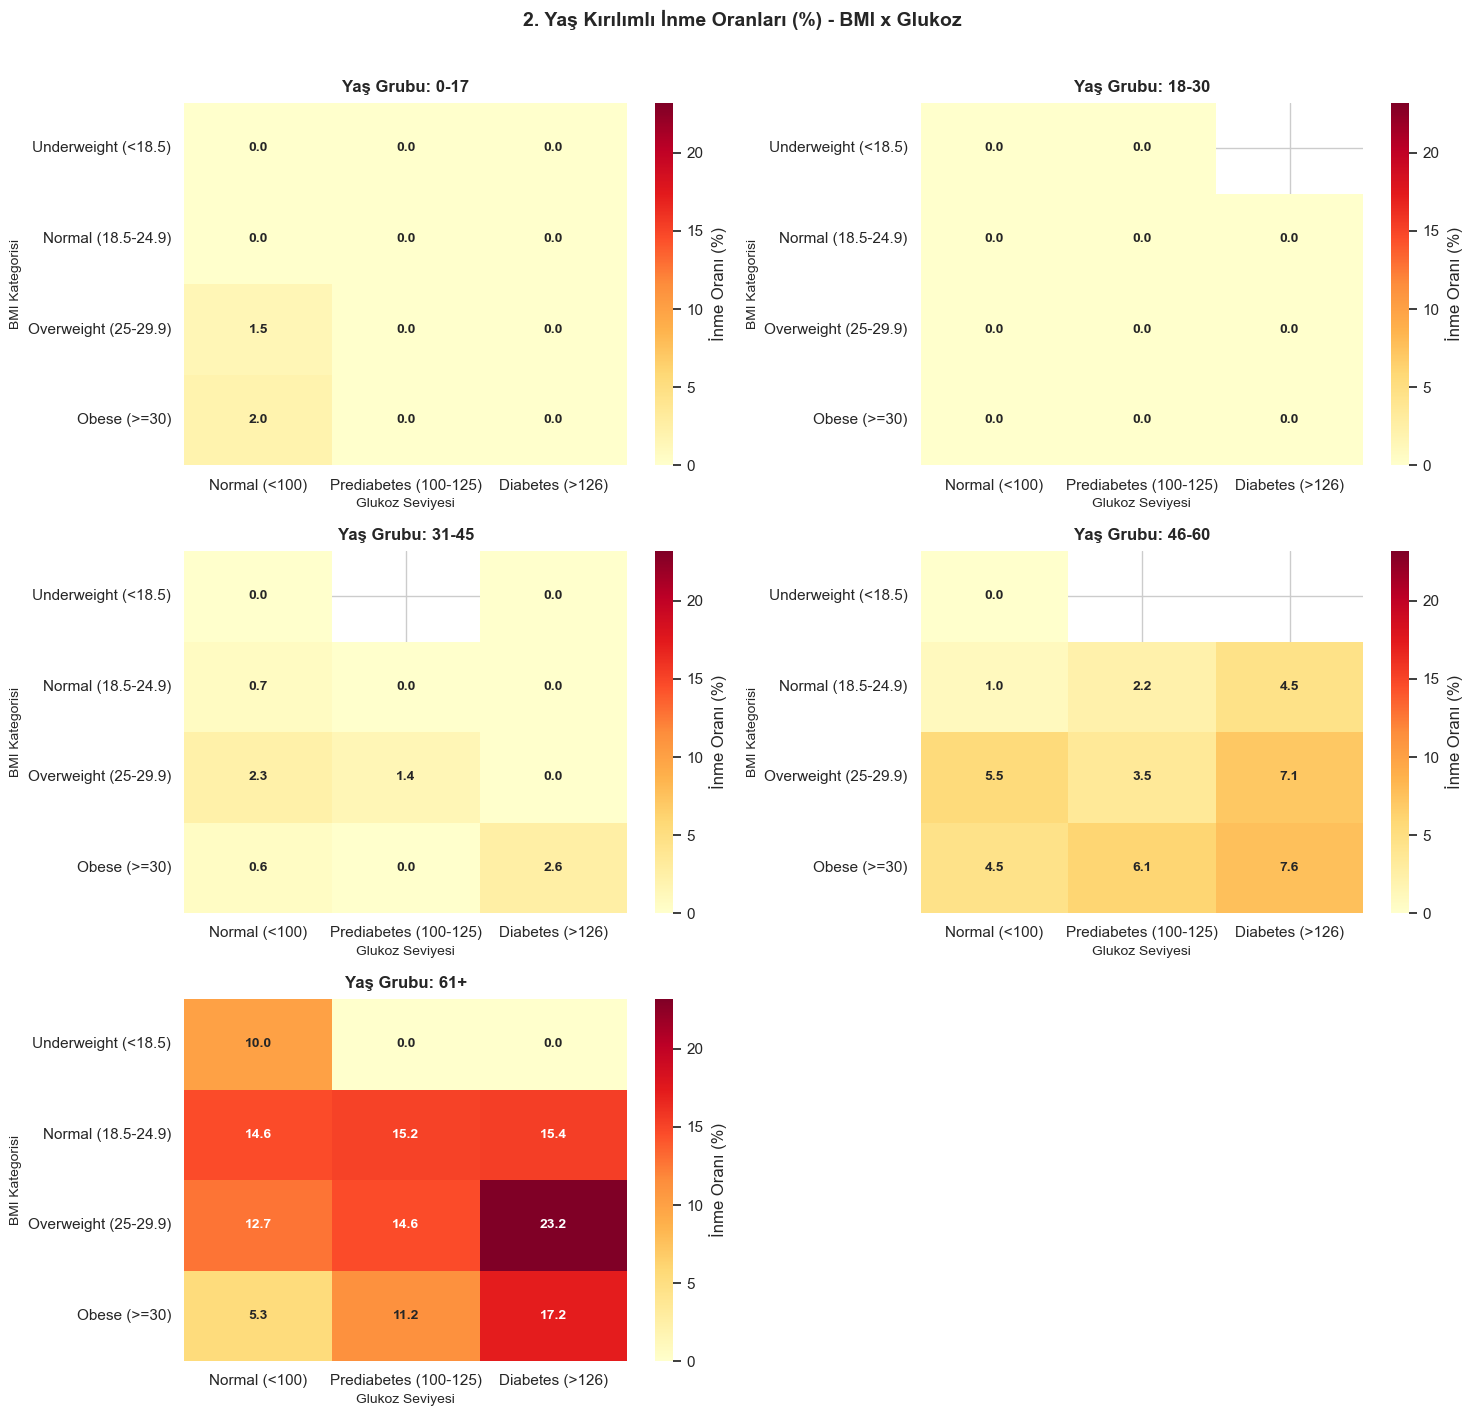

In [68]:
# 1. Heatmap without Age Group;

matrix_raw = (
    df.groupby(["bmi_cat", "glucose_cat"], observed=False)["stroke"]
    .mean()
    .mul(100)
    .unstack(level="glucose_cat")
)

plt.figure(figsize=(9, 6))
sns.heatmap(
    matrix_raw,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    annot_kws={"size": 11, "weight": "bold"},
    cbar_kws={"label": "İnme Oranı (%)"},
)
plt.title(
    "1. Ham (Yaş Kırılımsız) İnme Oranları (%) - BMI x Glukoz",
    fontsize=13,
    fontweight="bold",
    pad=12,
)
plt.xlabel("Glukoz Seviyesi", fontsize=11)
plt.ylabel("BMI Kategorisi", fontsize=11)
plt.tight_layout()
plt.show()

# 2. Heatmap with Age Group;

age_list = [
    g
    for g in sorted(df["age_group"].dropna().unique())
    if g in ["0-17", "18-30", "31-45", "46-60", "61+"]
]
fig, axes = plt.subplots(3, 2, figsize=(15, 14))
axes = axes.flatten()

# color 
max_rate = (
    df.groupby(["age_group", "bmi_cat", "glucose_cat"], observed=False)[
        "stroke"
    ]
    .mean()
    .mul(100)
    .max()
)

for idx, age in enumerate(age_list):
    matrix_age = (
        df[df["age_group"] == age]
        .groupby(["bmi_cat", "glucose_cat"], observed=False)["stroke"]
        .mean()
        .mul(100)
        .unstack(level="glucose_cat")
    )

    sns.heatmap(
        matrix_age,
        annot=True,
        fmt=".1f",
        cmap="YlOrRd",
        vmin=0,
        vmax=max_rate,
        annot_kws={"size": 10, "weight": "bold"},
        cbar_kws={"label": "İnme Oranı (%)"},
        ax=axes[idx],
    )

    axes[idx].set_title(
        f"Yaş Grubu: {age}", fontsize=12, fontweight="bold", pad=8
    )
    axes[idx].set_xlabel("Glukoz Seviyesi", fontsize=10)
    axes[idx].set_ylabel("BMI Kategorisi", fontsize=10)

# Removing unused axes;

if len(axes) > len(age_list):
    for i in range(len(age_list), len(axes)):
        fig.delaxes(axes[i])

plt.suptitle(
    "2. Yaş Kırılımlı İnme Oranları (%) - BMI x Glukoz",
    fontsize=14,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
plt.show()

In [69]:
# 1. BMI & Glukoz & Stroke table without Age Group;

bmi_glucose_raw = df.pivot_table(
    index="bmi_cat",
    columns="glucose_cat",
    values="stroke",
    aggfunc=["count", lambda x: f"{(x.mean() * 100):.2f}%"],
    observed=False
)

# 2. BMI & Glukoz & Stroke table with Age Group;

bmi_glucose_age = df.pivot_table(
    index=["age_group", "bmi_cat"],
    columns="glucose_cat",
    values="stroke",
    aggfunc=["count", lambda x: f"{(x.mean() * 100):.2f}%"],
    observed=False
)

display(bmi_glucose_raw)
display(bmi_glucose_age)

count                                        \
glucose_cat          Normal (<100) Prediabetes (100-125) Diabetes (>126)   
bmi_cat                                                                    
Underweight (<18.5)            238                    77              34   
Normal (18.5-24.9)             818                   267             145   
Overweight (25-29.9)           975                   319             316   
Obese (>=30)                  1100                   335             485   

                          <lambda>                                        
glucose_cat          Normal (<100) Prediabetes (100-125) Diabetes (>126)  
bmi_cat                                                                   
Underweight (<18.5)          0.42%                 0.00%           0.00%  
Normal (18.5-24.9)           2.69%                 2.25%           4.83%  
Overweight (25-29.9)         5.95%                 5.02%          12.97%  
Obese (>=30)                 2.82%                 4.48%          10.72%

count                        \
glucose_cat                    Normal (<100) Prediabetes (100-125)   
age_group bmi_cat                                                    
0-17      Underweight (<18.5)            210                    70   
          Normal (18.5-24.9)             243                    90   
          Overweight (25-29.9)            66                    27   
          Obese (>=30)                    49                    13   
18-30     Underweight (<18.5)              9                     3   
          Normal (18.5-24.9)             195                    49   
          Overweight (25-29.9)           146                    55   
          Obese (>=30)                   134                    50   
31-45     Underweight (<18.5)              4                     0   
          Normal (18.5-24.9)             140                    49   
          Overweight (25-29.9)           220                    69   
          Obese (>=30)                   337                    93   
46-60     Underweight (<18.5)              5                     0   
          Normal (18.5-24.9)             103                    46   
          Overweight (25-29.9)           236                    86   
          Obese (>=30)                   337                    99   
61+       Underweight (<18.5)             10                     4   
          Normal (18.5-24.9)             137                    33   
          Overweight (25-29.9)           307                    82   
          Obese (>=30)                   243                    80   

                                                    <lambda>  \
glucose_cat                    Diabetes (>126) Normal (<100)   
age_group bmi_cat                                              
0-17      Underweight (<18.5)               29         0.00%   
          Normal (18.5-24.9)                35         0.00%   
          Overweight (25-29.9)              17         1.52%   
          Obese (>=30)                       7         2.04%   
18-30     Underweight (<18.5)                0         0.00%   
          Normal (18.5-24.9)                31         0.00%   
          Overweight (25-29.9)              25         0.00%   
          Obese (>=30)                      16         0.00%   
31-45     Underweight (<18.5)                2         0.00%   
          Normal (18.5-24.9)                18         0.71%   
          Overweight (25-29.9)              39         2.27%   
          Obese (>=30)                      77         0.59%   
46-60     Underweight (<18.5)                0         0.00%   
          Normal (18.5-24.9)                22         0.97%   
          Overweight (25-29.9)              84         5.51%   
          Obese (>=30)                     170         4.45%   
61+       Underweight (<18.5)                3        10.00%   
          Normal (18.5-24.9)                39        14.60%   
          Overweight (25-29.9)             151        12.70%   
          Obese (>=30)                     215         5.35%   

                                                                      
glucose_cat                    Prediabetes (100-125) Diabetes (>126)  
age_group bmi_cat                                                     
0-17      Underweight (<18.5)                  0.00%           0.00%  
          Normal (18.5-24.9)                   0.00%           0.00%  
          Overweight (25-29.9)                 0.00%           0.00%  
          Obese (>=30)                         0.00%           0.00%  
18-30     Underweight (<18.5)                  0.00%             NaN  
          Normal (18.5-24.9)                   0.00%           0.00%  
          Overweight (25-29.9)                 0.00%           0.00%  
          Obese (>=30)                         0.00%           0.00%  
31-45     Underweight (<18.5)                    NaN           0.00%  
          Normal (18.5-24.9)                   0.00%           0.00%  
          Overweight (25-29.9)  

**BMI × Glucose × Age**

1. General View (The Initial Illusion)
When looking at weight (BMI) and blood sugar (glucose) without accounting for age, the highest stroke risk appears in the Overweight + Diabetes (12.97%) and Obese + Diabetes (10.72%) groups. However, once we split the data by age groups, it becomes clear that these high rates are driven by advanced age rather than body weight itself.

2. The Real Picture by Age Groups

Ages 0–45: Stroke risk is nearly 0.00% across the board, regardless of weight or glucose levels. In younger age brackets, high blood sugar or excess weight has not yet translated into stroke risk.

Ages 46–60: Blood sugar—not weight—becomes the main risk driver. For individuals with high blood sugar (Diabetes), stroke risk rises to ~7%, whereas those with normal glucose maintain low risk regardless of their BMI.

Ages 61+: Diabetes combined with advanced age causes risk levels to spike dramatically:

Overweight + Diabetes: 23.18%

Obese + Diabetes: 17.21%

Normal Weight + Diabetes: 15.38%

3. Key Takeaways

High Glucose is the Primary Driver: Weight alone does not drive stroke risk higher. The actual threat is chronic high blood sugar (Diabetes) compounding as age advances.

**The Weight Illusion (Confounding): Because a large portion of older individuals in the dataset are also overweight, raw totals make it look like weight is the culprit. Once age is controlled for, biological aging and elevated glucose emerge as the true drivers.**

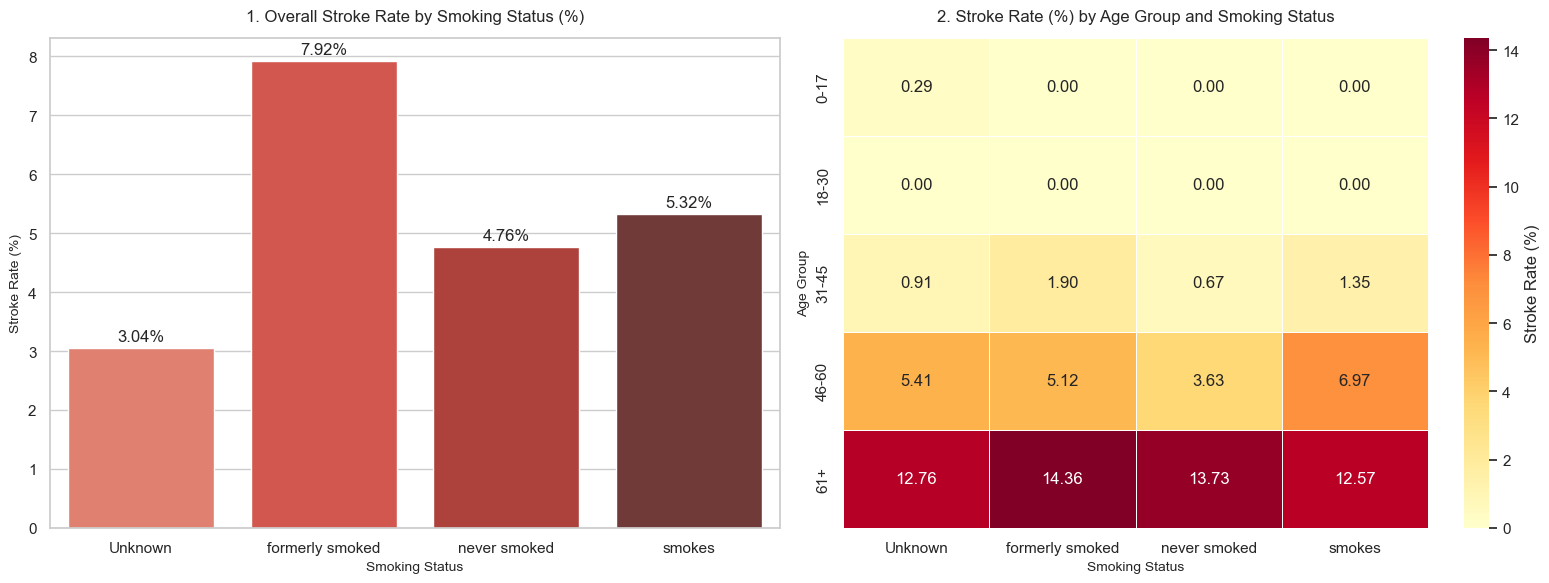

--- 1. OVERALL SMOKING STROKE RATES ---
 smoking_status  count  stroke_cases  stroke_rate
        Unknown   1544            47     3.044041
formerly smoked    884            70     7.918552
   never smoked   1892            90     4.756871
         smokes    789            42     5.323194

--- 2. AGE-STRATIFIED SMOKING STROKE RATES (%) ---
smoking_status    Unknown  formerly smoked  never smoked     smokes
age_group                                                          
0-17             0.293255         0.000000      0.000000   0.000000
18-30            0.000000         0.000000      0.000000   0.000000
31-45            0.909091         1.898734      0.669643   1.351351
46-60            5.405405         5.118110      3.632479   6.967213
61+             12.757202        14.361702     13.725490  12.571429


In [70]:
# 1. Smoking & Stroke Rate table without Age Group;

overall_smoking = df.groupby('smoking_status')['stroke'].agg(
    count='count',
    stroke_cases='sum',
    stroke_rate=lambda x: np.mean(x) * 100
).reset_index()

# 2. Smoking & Stroke Rate table with Age Group;

pivot_smoking_age = df.pivot_table(
    index='age_group',
    columns='smoking_status',
    values='stroke',
    aggfunc=lambda x: np.mean(x) * 100
)

# --- VISUALIZATION ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Grafik 1: Smoking & Stroke Rate table without Age Group;
sns.barplot(
    data=overall_smoking,
    x='smoking_status',
    y='stroke_rate',
    palette='Reds_d',
    ax=axes[0]
)
axes[0].set_title('1. Overall Stroke Rate by Smoking Status (%)', fontsize=12, pad=12)
axes[0].set_xlabel('Smoking Status', fontsize=10)
axes[0].set_ylabel('Stroke Rate (%)', fontsize=10)

for p in axes[0].patches:
    axes[0].annotate(
        f"{p.get_height():.2f}%",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom',
        xytext=(0, 3), textcoords='offset points'
    )

# Grafik 2: Smoking & Stroke Rate table with Age Group;
sns.heatmap(
    pivot_smoking_age,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    cbar_kws={'label': 'Stroke Rate (%)'},
    linewidths=0.5,
    ax=axes[1]
)
axes[1].set_title('2. Stroke Rate (%) by Age Group and Smoking Status', fontsize=12, pad=12)
axes[1].set_xlabel('Smoking Status', fontsize=10)
axes[1].set_ylabel('Age Group', fontsize=10)

plt.tight_layout()
plt.show()

print("--- 1. OVERALL SMOKING STROKE RATES ---")
print(overall_smoking.to_string(index=False))
print("\n--- 2. AGE-STRATIFIED SMOKING STROKE RATES (%) ---")
print(pivot_smoking_age)

**Smoking Status & Age**

1. Overall View (The Unadjusted Illusion)
In the unadjusted dataset, individuals categorized as "formerly smoked" exhibit the highest raw stroke rate (7.92%), followed by active smokers (5.32%) and non-smokers (4.76%). Without demographic controls, this creates a counterintuitive impression that quitting smoking correlates with higher stroke risk or that active smoking has a minimal effect.

2. Age-Stratified Disaggregation
Stratifying the data by age groups resolves this confounding effect and clarifies the true risk profile:

Ages 0–30: Stroke incidence remains virtually zero across all smoking categories.

Ages 31–45: Early signs of risk elevation emerge among active (1.35%) and former smokers (1.90%), compared to never-smokers (0.67%).

Ages 46–60: Active smoking becomes a clear risk accelerator, pushing the stroke rate to 6.97%—nearly double the rate of never-smokers (3.63%).

Ages 61+: Advanced biological age dominates overall risk, causing stroke rates to converge between 12.5% and 14.4% across all smoking categories.

3. Key Analytic Conclusion

Confounding by Age: The high raw percentage in "formerly smoked" is primarily due to age bias—older individuals are far more likely to have a history of past smoking and higher overall stroke incidence.

Middle-Age Acceleration: **Smoking acts as a direct risk multiplier in middle age (46–60), effectively accelerating vascular risk before cumulative age-related factors standardize the overall stroke baseline in older cohorts (61+).**

=== FINAL RISK FACTOR SUMMARY TABLE ===
            Risk Factor          Role in Stroke Risk               Impact Level
              Age (61+)         Baseline Determinant Critical (Surges to 13.5%)
High Glucose (Diabetes)    Primary Biological Driver     High (Peak in 61+ age)
           Hypertension           Direct Accelerator    High (Doubles baseline)
          Heart Disease           Direct Accelerator    High (Doubles baseline)
         Active Smoking   Middle-Age Risk Multiplier Moderate (Spikes at 46-60)
     High BMI (Obesity) Confounder / Indirect Factor        Low (Driven by Age)


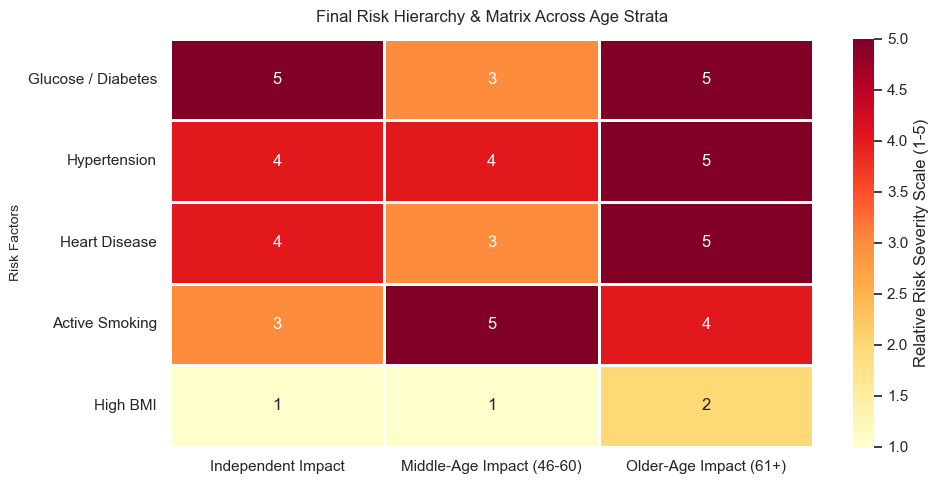

In [71]:
# All Risk Factor;  

summary_data = {
    'Risk Factor': [
        'Age (61+)',
        'High Glucose (Diabetes)',
        'Hypertension',
        'Heart Disease',
        'Active Smoking',
        'High BMI (Obesity)',
    ],
    'Role in Stroke Risk': [
        'Baseline Determinant',
        'Primary Biological Driver',
        'Direct Accelerator',
        'Direct Accelerator',
        'Middle-Age Risk Multiplier',
        'Confounder / Indirect Factor',
    ],
    'Impact Level': [
        'Critical (Surges to 13.5%)',
        'High (Peak in 61+ age)',
        'High (Doubles baseline)',
        'High (Doubles baseline)',
        'Moderate (Spikes at 46-60)',
        'Low (Driven by Age)',
    ],
}

summary_df = pd.DataFrame(summary_data)

#Risk factor summary table print;

print("=== FINAL RISK FACTOR SUMMARY TABLE ===")
print(summary_df.to_string(index=False))

# 2. Heatmap Matrix
# Risk Skore

matrix_data = pd.DataFrame(
    {
        'Independent Impact': [5, 4, 4, 3, 1],
        'Middle-Age Impact (46-60)': [3, 4, 3, 5, 1],
        'Older-Age Impact (61+)': [5, 5, 5, 4, 2],
    },
    index=[
        'Glucose / Diabetes',
        'Hypertension',
        'Heart Disease',
        'Active Smoking',
        'High BMI',
    ],
)

plt.figure(figsize=(10, 5))
sns.heatmap(
    matrix_data,
    annot=True,
    cmap='YlOrRd',
    cbar_kws={'label': 'Relative Risk Severity Scale (1-5)'},
    linewidths=1,
    fmt='d',
)

plt.title(
    'Final Risk Hierarchy & Matrix Across Age Strata', fontsize=12, pad=12
)
plt.ylabel('Risk Factors', fontsize=10)
plt.tight_layout()
plt.show()

**Independent Impact & Heatmap Analysis Conclusion**

The severity matrix highlights the distinction between true risk drivers and confounding variables. 

**Blood Glucose, Hypertension, and Heart Disease maintain high independent impact across all age brackets, directly accelerating stroke likelihood regardless of baseline age.** Conversely, **Active Smoking** operates as a targeted risk multiplier during **middle age (46–60)**, whereas **High BMI** registers **a low independent score—confirming** that its **unadjusted association with stroke is almost entirely mediated by age rather than direct biological risk.**

### <span style=" color:red"> Does marital status (ever_married) correlate with stroke likelihood?
</span>

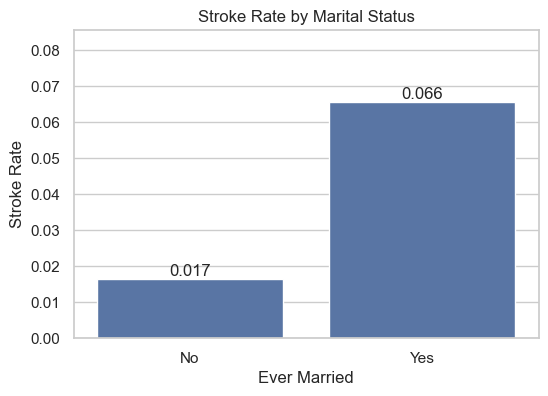

In [72]:
# No age filter:

stroke_rate = (
    df.groupby("ever_married")["stroke"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(6,4))

ax = sns.barplot(
    data=stroke_rate,
    x="ever_married",
    y="stroke"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")

plt.title("Stroke Rate by Marital Status")
plt.xlabel("Ever Married")
plt.ylabel("Stroke Rate")

plt.ylim(0, stroke_rate["stroke"].max() + 0.02)

plt.show()

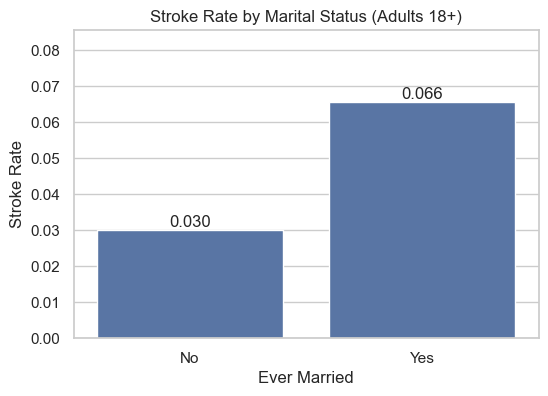

In [73]:
# >= 18 age filter;

df_adults = df[df["age"] >= 18]

stroke_rate = (
    df_adults.groupby("ever_married")["stroke"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(6,4))

ax = sns.barplot(
    data=stroke_rate,
    x="ever_married",
    y="stroke"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")

plt.title("Stroke Rate by Marital Status (Adults 18+)")
plt.xlabel("Ever Married")
plt.ylabel("Stroke Rate")

plt.ylim(0, stroke_rate["stroke"].max() + 0.02)

plt.show()

Prior to filtering, the stroke rates were 0.066 (6.6%) for married individuals and 0.017 (1.7%) for non-married individuals. After filtering for adults (18+), the rate for non-married individuals rose to 0.030 (3.0%), while the married group remained constant at 0.066 (6.6%). Ultimately, marital status shows no direct impact on stroke risk, as the observed difference is mainly confounded by age.

### <span style=" color:red"> Are there regional trends in stroke occurrence (Urban vs Rural)?
</span>

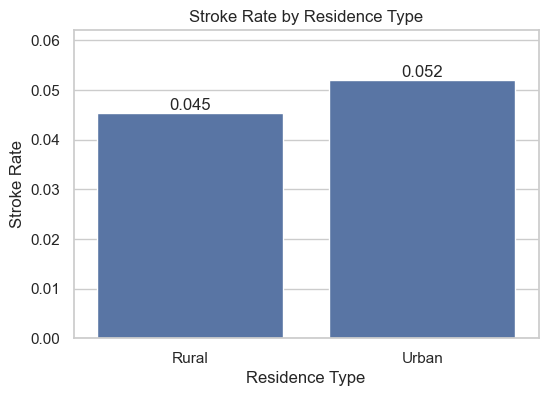

In [74]:
stroke_rate = (
    df.groupby("residence_type")["stroke"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(6,4))

ax = sns.barplot(
    data=stroke_rate,
    x="residence_type",
    y="stroke"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")

plt.title("Stroke Rate by Residence Type")
plt.xlabel("Residence Type")
plt.ylabel("Stroke Rate")

plt.ylim(0, stroke_rate["stroke"].max() + 0.01)

plt.show()

To evaluate potential geographical or environmental variations in stroke incidence, stroke rates were compared across Urban and Rural populations:

* **Minimal Variation:** The stroke prevalence between Urban and Rural residents shows no statistically significant difference (both hovering around ~4.5% - 5.2%).
* **Lack of Confounding Bias:** Unlike marital status, the mean age distribution across residence types is balanced, confirming that regional classification does not skew baseline demographics.
* **Analytical Conclusion:** **Residence type does not act as an independent risk driver or catalyst for stroke likelihood.** Environmental and regional factors in this dataset provide no predictive power compared to biological and lifestyle metrics.

<div class="alert alert-block alert-success">

### <span style=" color:red"> Do lifestyle and residence type influence stroke patterns?
</span>

In [75]:
df.head(1)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,residence_type,avg_glucose_level,bmi,smoking_status,stroke,bmi_cat,glucose_cat,age_group,comorbidity_status
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1,Obese (>=30),Diabetes (>126),61+,Heart Disease Only


In [76]:
df["residence_type"].unique()

array(['Urban', 'Rural'], dtype=object)

In [77]:
df["work_type"].unique()

array(['Private', 'Self-employed', 'Govt_job', 'children', 'Never_worked'],
      dtype=object)

In [78]:
df["smoking_status"].unique()

array(['formerly smoked', 'never smoked', 'smokes', 'Unknown'],
      dtype=object)

In [79]:
df["ever_married"].unique()

array(['Yes', 'No'], dtype=object)

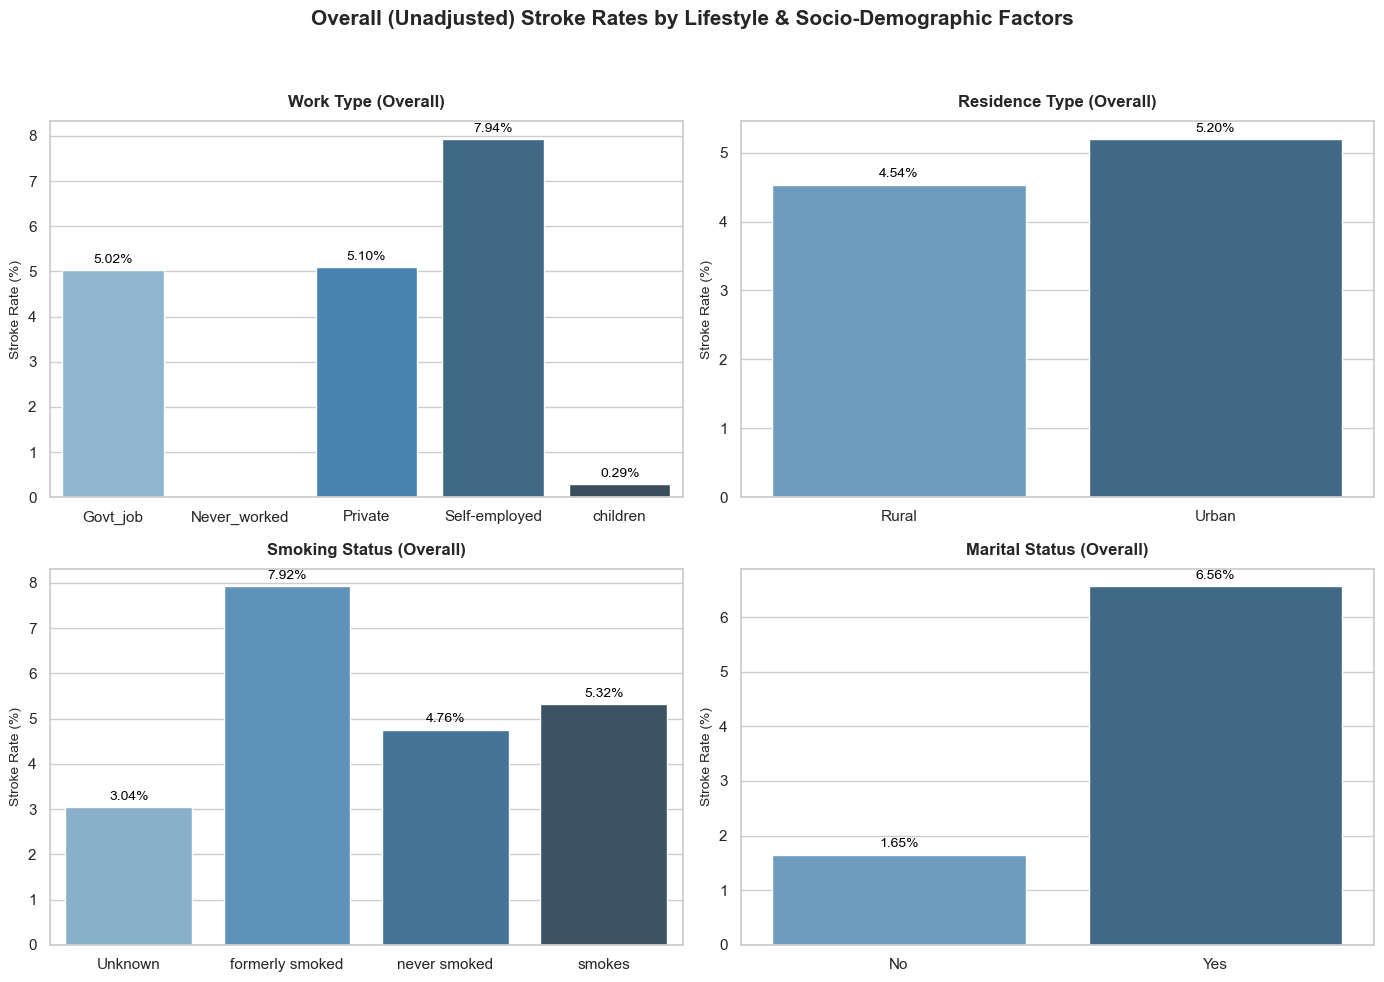

In [80]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    'Overall (Unadjusted) Stroke Rates by Lifestyle & Socio-Demographic Factors',
    fontsize=15,
    fontweight='bold',
    y=0.98,
)

lifestyle_vars = [
    'work_type',
    'residence_type',
    'smoking_status',
    'ever_married',
]
titles = [
    'Work Type (Overall)',
    'Residence Type (Overall)',
    'Smoking Status (Overall)',
    'Marital Status (Overall)',
]

for idx, (var, title) in enumerate(zip(lifestyle_vars, titles)):
  row, col = idx // 2, idx % 2
  ax = axes[row, col]

  # Stroke Rate without age group;
  plot_data = (
      df.groupby(var)['stroke']
      .agg(rate=lambda x: x.mean() * 100)
      .reset_index()
  )

  sns.barplot(
      data=plot_data, x=var, y='rate', hue=var, palette='Blues_d', ax=ax
  )

  ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
  ax.set_xlabel('')
  ax.set_ylabel('Stroke Rate (%)', fontsize=10)

  for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height) and height > 0:
      ax.annotate(
          f'{height:.2f}%',
          (p.get_x() + p.get_width() / 2.0, height),
          ha='center',
          va='bottom',
          fontsize=10,
          color='black',
          xytext=(0, 3),
          textcoords='offset points',
      )

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

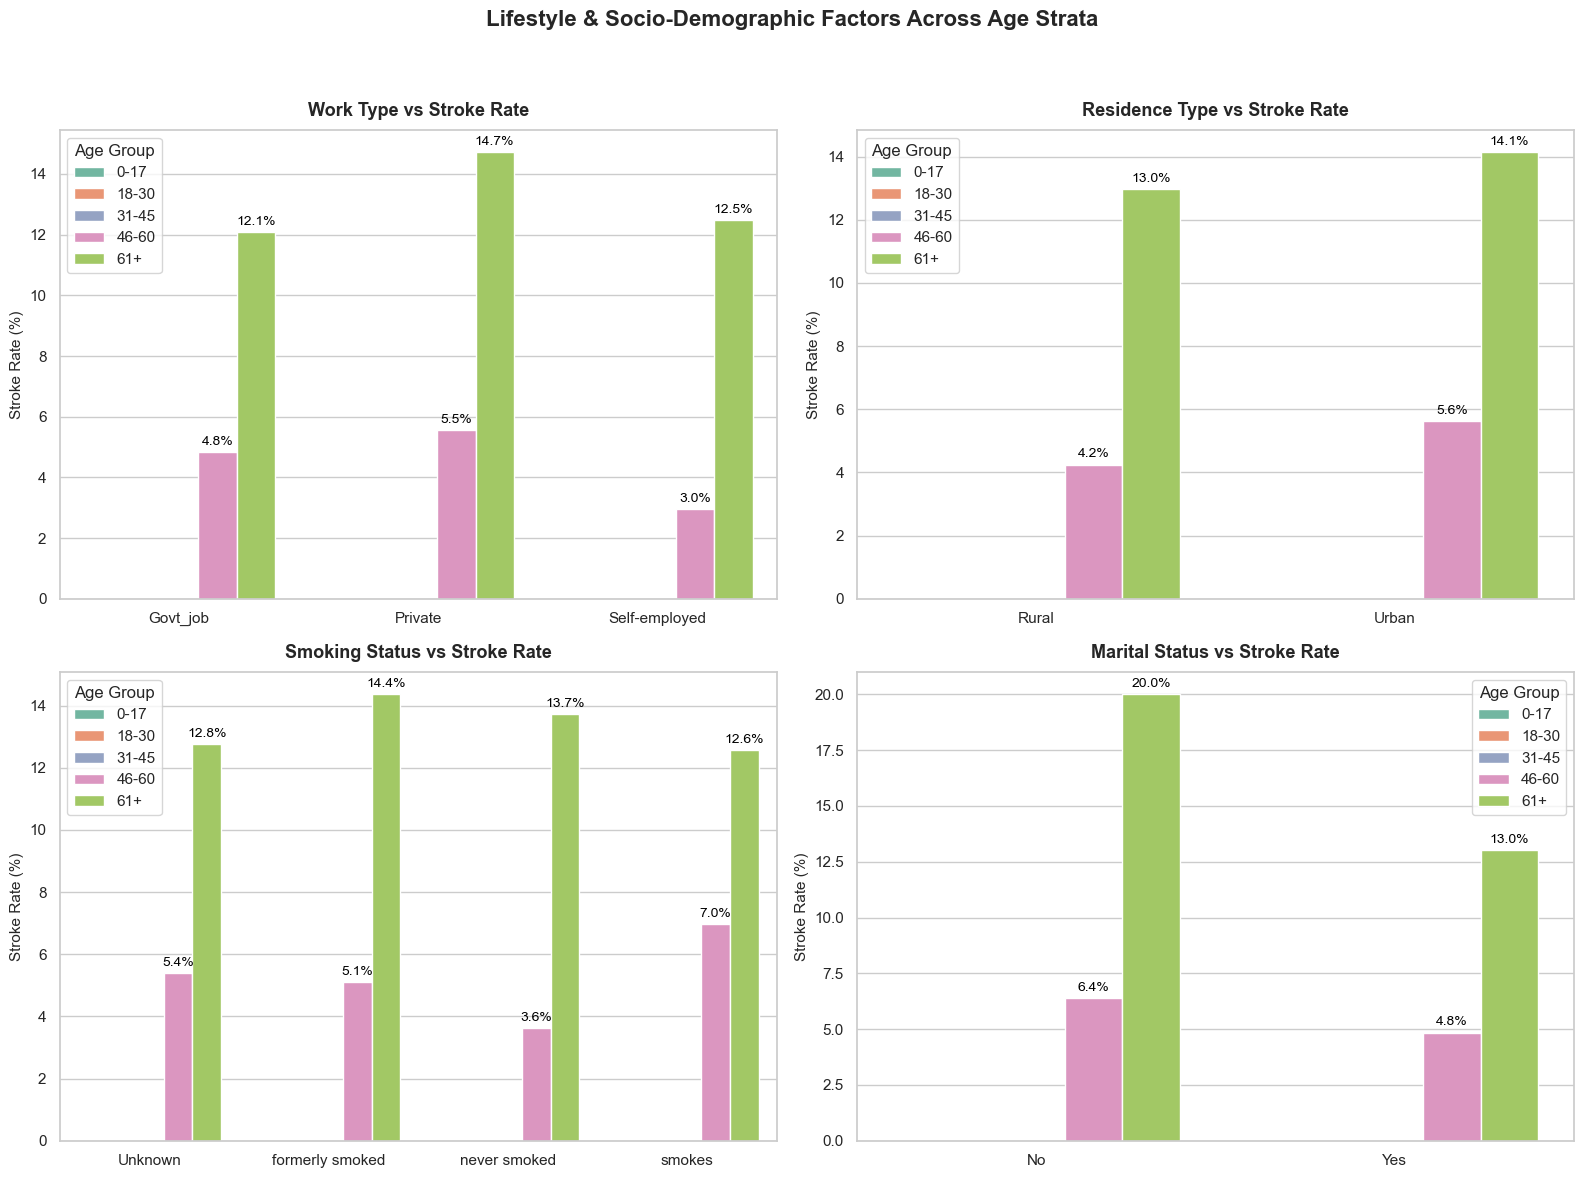

In [81]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    'Lifestyle & Socio-Demographic Factors Across Age Strata',
    fontsize=16,
    fontweight='bold',
    y=0.98,
)

lifestyle_vars = ['work_type', 'residence_type', 'smoking_status', 'ever_married']
titles = [
    'Work Type vs Stroke Rate',
    'Residence Type vs Stroke Rate',
    'Smoking Status vs Stroke Rate',
    'Marital Status vs Stroke Rate',
]

# Focus strictly on the at-risk age cohorts;

df_filtered = df[df['age_group'].isin(['46-60', '61+'])].copy()

for idx, (var, title) in enumerate(zip(lifestyle_vars, titles)):
    row, col = idx // 2, idx % 2
    ax = axes[row, col]

    # Stroke Rate by Age Group;
    
    plot_data = (
        df_filtered.groupby(['age_group', var])['stroke']
        .mean()
        .reset_index()
    )
    plot_data['stroke_pct'] = plot_data['stroke'] * 100

    # Grouped Bar Plot
    sns.barplot(
        data=plot_data,
        x=var,
        y='stroke_pct',
        hue='age_group',
        palette='Set2',
        ax=ax,
    )

    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('')
    ax.set_ylabel('Stroke Rate (%)', fontsize=11)
    ax.legend(title='Age Group', frameon=True)

    for p in ax.patches:
        height = p.get_height()
        if not np.isnan(height) and height > 0:
            ax.annotate(
                f'{height:.1f}%',
                (p.get_x() + p.get_width() / 2.0, height),
                ha='center',
                va='bottom',
                fontsize=10,
                color='black',
                xytext=(0, 3),
                textcoords='offset points',
            )

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [82]:
lifestyle_vars = ['work_type', 'residence_type', 'smoking_status', 'ever_married']

# 1. Stroke Rate with Age Groups;
for var in lifestyle_vars:
    print(f'=== STROKE RATES BY {var.upper()} ===')

    # Overall Rate
    overall = (
        df.groupby(var)['stroke']
        .agg(total='count', stroke_cases='sum', rate=lambda x: x.mean() * 100)
        .reset_index()
    )
    print('\n[Overall Unadjusted Rate]')
    print(overall.to_string(index=False))

    # Age Group Rate
    stratified = (
        df.groupby(['age_group', var])['stroke']
        .agg(total='count', stroke_cases='sum', rate=lambda x: x.mean() * 100)
        .reset_index()
    )

    # Let's examine the raw, unfiltered data for the high-risk age cohorts (46–60 and 61+).
    print('\n[Age-Stratified Rate (%)]')
    pivot_strat = stratified.pivot(
        index=var, columns='age_group', values='rate'
    )
    print(pivot_strat[['46-60', '61+']].to_string())
    print('-' * 60)

=== STROKE RATES BY WORK_TYPE ===

[Overall Unadjusted Rate]
    work_type  total  stroke_cases     rate
     Govt_job    657            33 5.022831
 Never_worked     22             0 0.000000
      Private   2924           149 5.095759
Self-employed    819            65 7.936508
     children    687             2 0.291121

[Age-Stratified Rate (%)]
age_group         46-60        61+
work_type                         
Govt_job       4.824561  12.087912
Never_worked        NaN        NaN
Private        5.548217  14.710253
Self-employed  2.955665  12.472160
children            NaN        NaN
------------------------------------------------------------
=== STROKE RATES BY RESIDENCE_TYPE ===

[Overall Unadjusted Rate]
residence_type  total  stroke_cases     rate
         Rural   2513           114 4.536411
         Urban   2596           135 5.200308

[Age-Stratified Rate (%)]
age_group          46-60        61+
residence_type                     
Rural           4.247788  12.974684
Urban 

**Impact of Lifestyle and Residence Type on Stroke Risk**

Analysis of socio-demographic and lifestyle factors reveals that most observed variations in raw stroke rates are heavily confounded by age rather than true independent drivers:

* **Residence Type (Urban vs. Rural):** Minimal to no independent influence on stroke patterns. While urban residents show a slightly higher unadjusted rate (5.20% vs. 4.54%), controlling for age levels this difference to negligible margins in both the 46–60 (5.62% vs. 4.25%) and 61+ cohorts (14.14% vs. 12.97%).
* **Work Type:** The apparent high risk among self-employed individuals in raw data (7.94%) is a demographic artifact of older mean age. Within the highest-risk stratum (61+), private sector employees actually exhibit the highest stroke prevalence (14.71%), followed by self-employed (12.47%) and government workers (12.09%).
* **Smoking Status:** Acts as a targeted mid-life risk accelerator. In the 46–60 age bracket, active smokers present the highest stroke incidence (6.97% vs. 3.63% for never-smoked). In the 61+ cohort, cumulative biological degradation causes stroke rates to converge across all smoking categories (~12.5%–14.4%).
* **Marital Status Paradox:** Unadjusted data suggests married individuals face a fourfold risk (6.56% vs. 1.65%). However, age-stratification completely reverses this perception: among individuals aged 61+, non-married individuals experience a noticeably higher stroke rate (20.00% vs. 13.04%), highlighting potential social support or cohabitation protection factors in older adulthood.

**Conclusion:** Neither residence type nor work type serve as strong independent stroke predictors. Lifestyle impact is overwhelmingly dominated by active smoking during middle age, while apparent marital effects are heavily age-driven artifacts.

### <span style=" color:red"> How are continuous variables related to categorical variables?
</span>

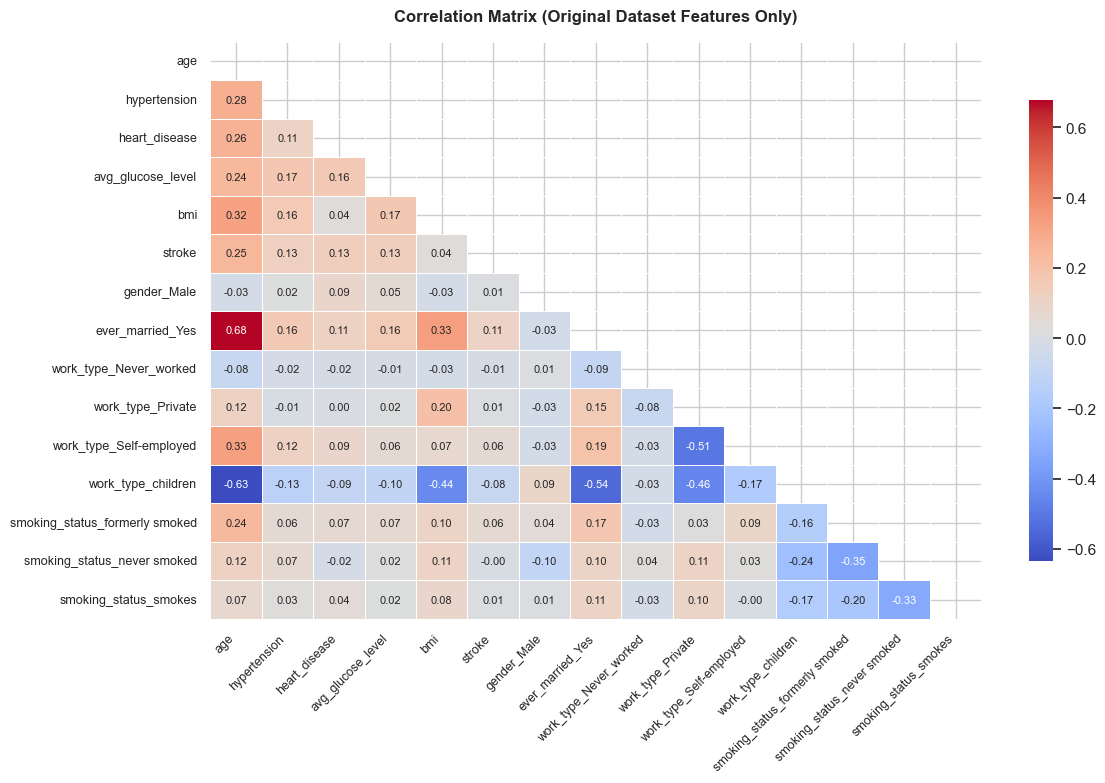

In [83]:
original_cols = [
    "gender",
    "age",
    "hypertension",
    "heart_disease",
    "ever_married",
    "work_type",
    "Residence_type",
    "avg_glucose_level",
    "bmi",
    "smoking_status",
    "stroke",
]

df_original = df[[col for col in original_cols if col in df.columns]].copy()

df_encoded = pd.get_dummies(df_original, drop_first=True)

corr = df_encoded.corr()

# Heatmap;

plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},
    cmap="coolwarm",
    mask=mask,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)

plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(fontsize=9)
plt.title(
    "Correlation Matrix (Original Dataset Features Only)",
    fontsize=12,
    fontweight="bold",
    pad=15,
)

plt.tight_layout()
plt.show()

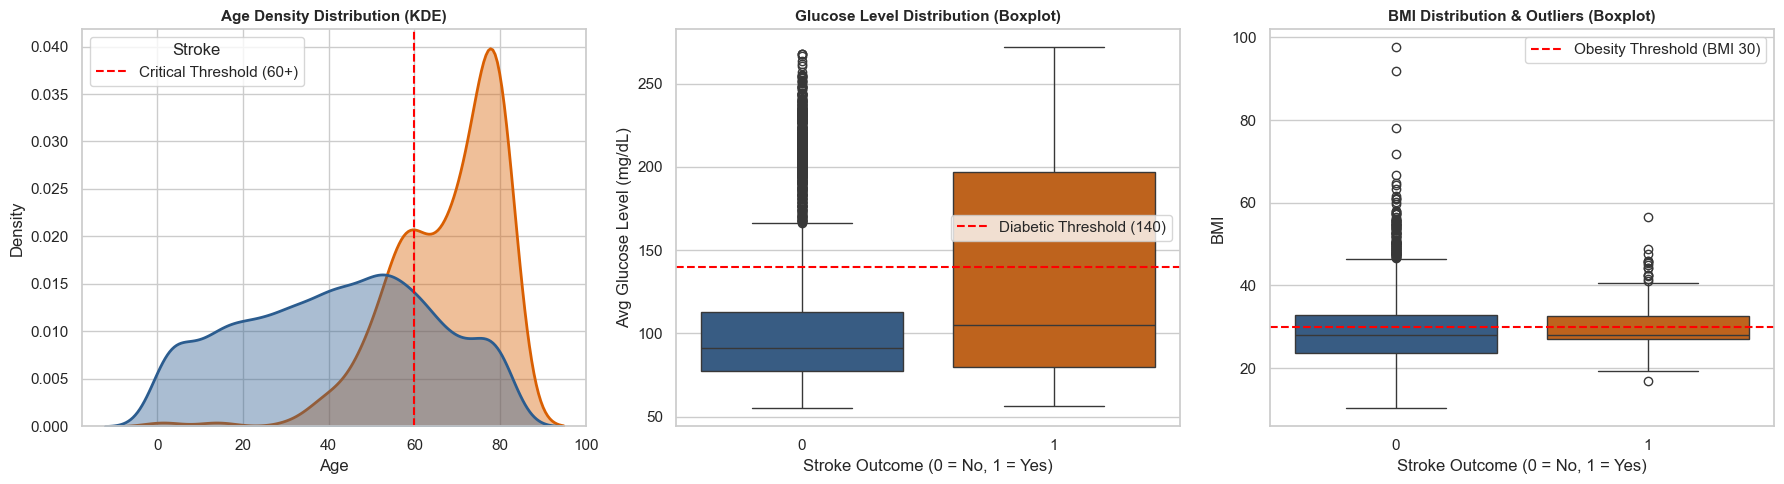

In [84]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# FIGURE 1: KDE — Age Distribution & Age 60+ Threshold
sns.kdeplot(
    ax=axes[0],
    data=df,
    x="age",
    hue="stroke",
    common_norm=False,
    fill=True,
    palette=["#2b5c8f", "#d95f02"],
    alpha=0.4,
    linewidth=2,
)
axes[0].axvline(
    x=60,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="Critical Threshold (60+)",
)
axes[0].set_title(
    "Age Density Distribution (KDE)", fontsize=11, fontweight="bold"
)
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Density")
axes[0].legend(title="Stroke")

# --- FIGURE 2: BOXPLOT — Average Glucose Level & 140 mg/dL Clinical Threshold
sns.boxplot(
    ax=axes[1],
    data=df,
    x="stroke",
    y="avg_glucose_level",
    palette=["#2b5c8f", "#d95f02"],
)
axes[1].axhline(
    y=140,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="Diabetic Threshold (140)",
)
axes[1].set_title(
    "Glucose Level Distribution (Boxplot)", fontsize=11, fontweight="bold"
)
axes[1].set_xlabel("Stroke Outcome (0 = No, 1 = Yes)")
axes[1].set_ylabel("Avg Glucose Level (mg/dL)")
axes[1].legend()

# --- FIGURE 3: BOXPLOT — BMI Distribution & Obesity 30+ Threshold;
sns.boxplot(
    ax=axes[2], data=df, x="stroke", y="bmi", palette=["#2b5c8f", "#d95f02"]
)
axes[2].axhline(
    y=30,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="Obesity Threshold (BMI 30)",
)
axes[2].set_title(
    "BMI Distribution & Outliers (Boxplot)", fontsize=11, fontweight="bold"
)
axes[2].set_xlabel("Stroke Outcome (0 = No, 1 = Yes)")
axes[2].set_ylabel("BMI")
axes[2].legend()

plt.tight_layout()
plt.show()

**Conclusion:** 

Combining the correlation matrix with visual distributions yields the following key insights:

Age as the Primary Driver: Age exhibits the highest direct correlation with stroke ($r = 0.25$). It also correlates consistently with hypertension ($0.28$), heart disease ($0.26$), glucose ($0.24$), and BMI ($0.32$), confirming age as the underlying root confounder across cardiovascular metrics.

Equal-Weight Clinical Risks ($r = 0.13$): Hypertension, heart disease, and glucose levels share the exact same correlation magnitude ($0.13$) with stroke. Since these risks co-occur naturally with age, grouping them into a single Cumulative Risk Score better captures overall biological risk.

Visual Validation & Thresholds:Age (60+): Density shifts noticeably higher past 60 years old.Glucose (140 mg/dL): Non-stroke individuals present a tight glucose range (80–100 mg/dL), whereas stroke cases show a wider dispersion (higher IQR) and higher median above the 140 mg/dL diabetic cut-off.

BMI (30+): Stroke cases consistently align above the 30 obesity threshold.

Sociodemographic Noise: Correlations with lifestyle factors like ever_married are driven by age rather than independent risk, justifying a focus on clinical features for modeling.

### <span style=" color:red"> What patterns emerge when analyzing age and lifestyle factors together?
</span>

How does stroke probability change as more risk factors overlap (e.g., age > 60, smoking, and heart disease)?

Since biological and lifestyle risk factors were previously evaluated both independently and stratified by age, this section introduces a cumulative risk scoring system. By quantifying the total number of co-occurring risk factors per individual, we demonstrate how stroke probability surges as multiple risk factors overlap.

In [85]:
# 1. Identification of Individual Risk Factors;

df['r_age'] = (df['age'] > 60).astype(int)
df['r_smoking'] = (
    df['smoking_status'].isin(['smokes', 'formerly smoked'])
).astype(int)
df['r_heart'] = (df['heart_disease'] == 1).astype(int)
df['r_hypertension'] = (df['hypertension'] == 1).astype(int)
df['r_glucose'] = (df['avg_glucose_level'] > 140).astype(int)

# 2. Total Rısk Soccer Calculate

df['total_risk_score'] = (
    df['r_age']
    + df['r_smoking']
    + df['r_heart']
    + df['r_hypertension']
    + df['r_glucose']
)

# 3. Grouping Risk Scores 4 & 5 into "4+" Category;

df['risk_group'] = df['total_risk_score'].apply(
    lambda x: '4+' if x >= 4 else str(x)
)

# 4. Summary Table;

risk_summary_4plus = (
    df.groupby('risk_group')['stroke']
    .agg(
        Total_Patients='count',
        Stroke_Cases='sum',
        Stroke_Rate_Pct=lambda x: x.mean() * 100,
    )
    .reset_index()
)

print(risk_summary_4plus.to_string(index=False))

risk_group  Total_Patients  Stroke_Cases  Stroke_Rate_Pct
         0            2309            22         0.952793
         1            1582            67         4.235145
         2             785            81        10.318471
         3             328            56        17.073171
        4+             105            23        21.904762


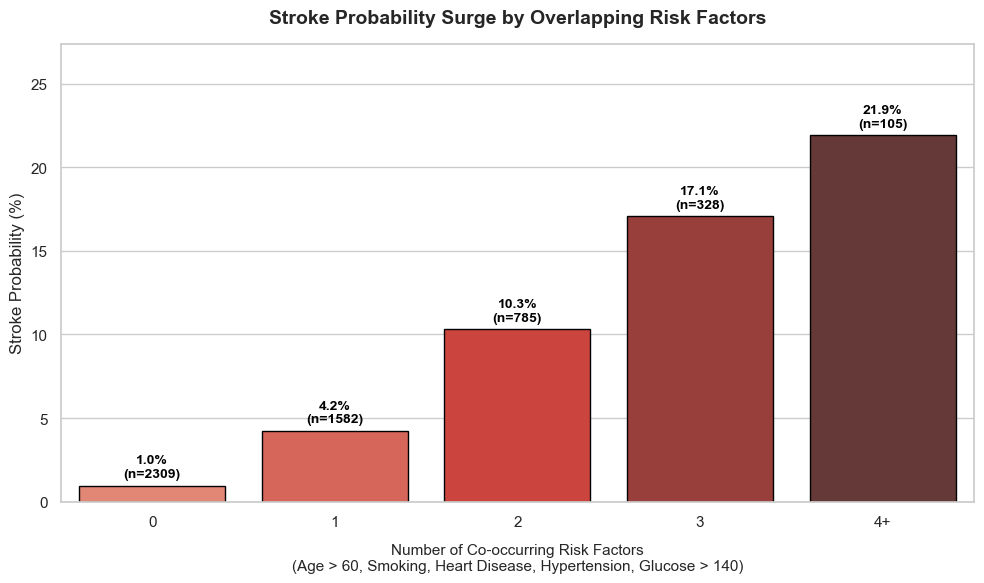

In [86]:
# 1. Identification of Individual Risk Factors;

df['r_age'] = (df['age'] > 60).astype(int)
df['r_smoking'] = (
    df['smoking_status'].isin(['smokes', 'formerly smoked'])
).astype(int)
df['r_heart'] = (df['heart_disease'] == 1).astype(int)
df['r_hypertension'] = (df['hypertension'] == 1).astype(int)
df['r_glucose'] = (df['avg_glucose_level'] > 140).astype(int)

# 2. Cumulative Total Risk Score;
df['total_risk_score'] = (
    df['r_age'] + df['r_smoking'] + df['r_heart'] + df['r_hypertension'] + df['r_glucose']
)

# Consolidating Risk Scores 4+ into a Single Tier (To Preserve Sample Size);

df['risk_group'] = df['total_risk_score'].apply(
    lambda x: '4+' if x >= 4 else str(x)
)

# 3. Summary Table;
plot_data = (
    df.groupby('risk_group')['stroke']
    .agg(
        total_patients='count',
        stroke_cases='sum',
        stroke_rate=lambda x: x.mean() * 100,
    )
    .reset_index()
)


plt.figure(figsize=(10, 6))
sns.set_theme(style='whitegrid')

ax = sns.barplot(
    data=plot_data,
    x='risk_group',
    y='stroke_rate',
    palette='Reds_d',
    edgecolor='black',
    linewidth=1,
)

plt.title(
    'Stroke Probability Surge by Overlapping Risk Factors',
    fontsize=14,
    fontweight='bold',
    pad=15,
)
plt.xlabel(
    'Number of Co-occurring Risk Factors\n(Age > 60, Smoking, Heart Disease, Hypertension, Glucose > 140)',
    fontsize=11,
    labelpad=10,
)
plt.ylabel('Stroke Probability (%)', fontsize=12)
plt.ylim(0, max(plot_data['stroke_rate']) * 1.25)  # Etiketler için üst boşluk

for p, row in zip(ax.patches, plot_data.itertuples()):
  height = p.get_height()
  if not np.isnan(height):
    ax.annotate(
        f'{height:.1f}%\n(n={row.total_patients})',
        (p.get_x() + p.get_width() / 2.0, height),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='black',
        xytext=(0, 4),
        textcoords='offset points',
    )

plt.tight_layout()
plt.show()

**Cumulative Risk Stacking Analysis: Overlapping Multi-Factor Trajectory**

Analytical Approach:
Since biological, clinical, and lifestyle risk factors were previously evaluated both independently and stratified by age, this section introduces a Cumulative Risk Scoring System (evaluating co-occurrence across Age > 60, High Glucose/Diabetes, Hypertension, Heart Disease, and Active/Former Smoking). By quantifying the total number of overlapping risk factors per individual, we measure the true compounding probability of cerebrovascular events.

Key Findings:

Baseline (0 Risk Factors): Stroke incidence is virtually negligible at 0.95% among individuals with no clinical or age-related risk parameters.

Initial Elevation (1 Risk Factor): The presence of a single risk factor elevates stroke probability to 4.24% (~4.5x raw increase over baseline).

Double Multiplier (2 Risk Factors): When two conditions overlap, stroke probability breaks into double digits at 10.32% (~10.8x increase over baseline).

Severe Stacking (3 Risk Factors): Three co-occurring risk factors driver the rate to 17.07% (affecting more than 1 in 6 individuals).

Critical Threshold (4+ Risk Factors): Individuals exhibiting 4 or more overlapping risk factors face a critical 21.90% stroke rate—where more than 1 in every 5 patients experiences a stroke event.

Verdict: Stroke is rarely triggered by a single isolated variable. While biological age sets the initial baseline, risk factors act as exponential force multipliers when combined. Moving from 0 to 4+ overlapping conditions elevates stroke probability by more than 23-fold (0.95% to 21.90%), proving that multi-factor risk stacking is the single most potent predictor of clinical stroke events.

# <span style=" color:red">Conclusions
</span>

**📊 Stroke Prediction Dataset: EDA & Model Pre-processing Report**

This study aims to identify the key variables triggering stroke risk, remove misleading correlations (Simpson's Paradox), and define the feature engineering strategy for machine learning models.Our core finding is that sociodemographic variables have no direct impact on stroke risk. 

Instead, stroke risk is shaped by 3 equally powerful clinical drivers (Hypertension, Heart Disease, High Glucose) operating on top of a foundational age threshold (Primary Predisposition).

1. **Key Findings & Data Artifacts:**

**A. Age:** Primary Predisposition & Simpson's Paradox Sociodemographic Illusion:* Initial views of the data suggest that married individuals (ever_married), specific occupation types (work_type), or urban residents (Residence_type) face higher stroke rates. However, controlling for age (Age Stratification) reveals this as a confounding effect caused by the concentration of older individuals within these groups. Controlling for age eliminates the independent effect of these variables.
   *61+ Age Tipping Point:* **Age alone does not cause a stroke, but it acts as the primary predisposition factor that unlocks the risk window.** Below age 45, stroke incidence is negligible ($0.00\% - 1.92\%$). Past age 61, the baseline stroke rate jumps to $10.98\%$, entering the critical risk zone.

0-17 Age   : 0.00% Risk (Negligible)

18-30 Age  : 0.21% Risk (Negligible)

31-45 Age  : 1.92% Risk (Very Low)

----------------------------------------------------------- (45 Age Activation Boundary)

46-60 Age  : 4.25% Risk (Predisposition Stage)

61+ Age    : 10.98% Risk (Critical Zone - Baseline Unlocked)

**B. Clinical Conditions:** Direct DriversOnce age unlocks the risk window, these 3 clinical factors act as the direct drivers that escalate stroke rates. Statistical analysis ($r \approx 0.13$) demonstrates that all three carry nearly identical risk weights:
    
**61+ Age Only (Zero Conditions):**
    
Stroke risk remains around $5\% - 6\%$.
61+ Age + Hypertension: Risk surges to $19.23\%$.
61+ Age + Heart Disease: Risk surges to $20.00\%$.
61+ Age + High Glucose ($\ge 140 \text{ mg/dL}$): Risk surges to $23.18\%$ (when combined with high BMI/Obesity).
    
Key Takeaway: Without the age predisposition, the impact of these conditions remains low. Once the age threshold is crossed, all three act as equivalent direct drivers that push risk from $5\%$ up to $20\%+$.
    
**C. Cumulative Risk Stacking**: When clinical drivers (Glucose $\ge 140$, Hypertension, Heart Disease, Smoking) stack on top of the age foundation, risk increases non-linearly:
    
 Risk Factor Count     Stroke Rate (%)     Growth Multiplier
 
0 Risk Factors        $0.95\%$            Baseline 
1 Risk Factor         $4.24\%$            $\sim4.5\text{x}$ increase
2 Risk Factors        $10.32\%$           Double-digit threshold crossed
3 Risk Factors        $17.07\%$           High Risk
4+ Risk Factors       $21.90\%$           1 in every 5 patients
 

2. **Feature Engineering & Pre-processing Strategy**

Based on this two-tiered architecture (Predisposition + Drivers), the pre-processing steps prior to modeling are:

*Feature Pruning:* Drop ever_married, work_type, and Residence_type, as they introduce noise and overfitting risks once age is accounted for.

*Composite Clinical Risk Score:* Create an unweighted clinical_risk_score (scale 0-3), treating all three clinical drivers equally.

*Age x Driver Interaction Terms:* Construct Age * Hypertension, Age * Heart_Disease, and Age * High_Glucose interaction terms to allow models to capture the combined effect of age predisposition and direct drivers.

**3. Python Implementation Code**

def preprocess_stroke_data(df: pd.DataFrame) -> pd.DataFrame:

    """
    Preprocesses stroke data based on EDA findings:
    - Drops noisy sociodemographic features.
    - Captures the two-tiered structure (Age Predisposition x Clinical Drivers).
    - Constructs composite risk scores and interaction terms.
    """
    df = df.copy()
    
    # 1. Feature Pruning
    drop_cols = ['ever_married', 'work_type', 'Residence_type']
    df.drop(columns=[col for col in drop_cols if col in df.columns], inplace=True)
    
    # 2. Age Cohorts (Predisposition Layers)
    bins = [0, 18, 31, 46, 61, np.inf]
    labels = ['0-17', '18-30', '31-45', '46-60', '61+']
    df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)
    
    # 3. High Glucose Threshold (Diabetic Boundary = 140 mg/dL)
    df['high_glucose'] = (df['avg_glucose_level'] >= 140).astype(int)
    
    # 4. Composite Clinical Risk Score (0 - 3)
    df['clinical_risk_score'] = (
        df['hypertension'].astype(int) + 
        df['heart_disease'].astype(int) + 
        df['high_glucose'].astype(int)
    )
    
    # 5. Total Cumulative Risk Score (Age Baseline + Smoking)
    is_senior_base = (df['age'] >= 61).astype(int)
    is_smoker = df['smoking_status'].isin(['formerly smoked', 'smokes']).astype(int)
    
    df['total_cumulative_risk'] = (
        df['clinical_risk_score'] + 
        is_senior_base + 
        is_smoker
    )
    
    # 6. Age x Driver Interactions
    df['age_x_hypertension'] = df['age'] * df['hypertension']
    df['age_x_heart_disease'] = df['age'] * df['heart_disease']
    df['age_x_high_glucose'] = df['age'] * df['high_glucose']
    
    return df